# MCQ vs Chat Analysis (v2-300)

This notebook compares the `GENERAL_MODEL_ORDER_1` models across:

- MCQ (greedy decode logits)
- Chat (Gemma models)
- Qwen Chat `no_think`
- Qwen Chat `think`

Design notes:

- MCQ configs are reconstructed directly from the result CSVs (English + bf16 for apples-to-apples comparisons).
- Chat configs are reconstructed from the latest JSONL row per `item_id`, then collapsed to config level.
- Missing / non-applicable factor dimensions are left as `NaN` and rendered as blank cells in combined heatmaps.
- The primary apples-to-apples MCQ vs Chat comparison uses `english` + `bf16` MCQ as the reference slice.
- Bayesian summaries use a paired Bayesian bootstrap by default, with `baycomp` probabilities when available.
- Robust summaries include finite Monte Carlo paired-permutation p-values plus Benjamini-Hochberg q-values within each exported comparison table.
- MCQ-linked aligned contrasts are intentionally conservative and have small per-model overlap (`n=12`), so per-model MCQ/chat findings should be treated as exploratory.
- Research-question summaries distinguish inferential paired tests from descriptive sensitivity/trend diagnostics.
- Terminology from our paper: *Logit distribution variance* (previously "Intrinsic Blur"), *Residual variance* (previously "Residual Jitter").

In [1]:
import json
import math
import re
import warnings
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path

import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Ellipse
from scipy.stats import wasserstein_distance

warnings.filterwarnings("ignore")


def resolve_project_root() -> Path:
    candidates = [
        Path("."),
        Path("./tasks/political-compass"),
    ]
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / "scorer.npz").exists() and (candidate / "output").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the political-compass project root from the current working directory."
    )


ROOT = resolve_project_root()
MCQ_RESULTS_DIR = ROOT / "output" / "mcq-v1-300" / "results"
CHAT_RESULTS_DIR = ROOT / "output" / "chat-v2-300"
PARAMS_PATH = ROOT / "scorer.npz"

OUTPUT_DIR = ROOT / "output" / "mcq-chat-v2-300"
PLOTS_DIR = OUTPUT_DIR / "analysis_plots"
TABLES_DIR = OUTPUT_DIR / "tables"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_QUESTIONS = 62
MCQ_REFERENCE_LANGUAGE = "english"
MCQ_REFERENCE_QUANT = "bf16"
BAYES_DRAWS = 20000
BAYES_ROPE = 0.25  # ROPE interval is [-0.25, +0.25] in Political Compass score units.
PERMUTATION_DRAWS = 5000
N_WORKERS = 8  # for parallel permutation tests

PRIMARY_BASE_MODELS = [
    "gemma-3-1b-it",
    "gemma-3-4b-it",
    "gemma-3-12b-it",
    "gemma-3-27b-it",
    "Qwen3-4B",
    "Qwen3-8B",
    "Qwen3-14B",
    "Qwen3-32B",
]

GEMMA_MODELS = [m for m in PRIMARY_BASE_MODELS if m.startswith("gemma")]
QWEN_MODELS = [m for m in PRIMARY_BASE_MODELS if m.startswith("Qwen")]

DISPLAY_NAMES = {
    "base": "Base Model",
    "authoritarian_left": "Auth Left",
    "authoritarian_right": "Auth Right",
    "libertarian_left": "Lib Left",
    "libertarian_right": "Lib Right",
    "centrism": "Centrism",
}

IDEOLOGY_COLORS = {
    "Base Model": "#555555",
    "Auth Left": "#d62728",
    "Auth Right": "#1f77b4",
    "Lib Left": "#2ca02c",
    "Lib Right": "#9467bd",
    "Centrism": "#7f7f7f",
}

FACTOR_LABELS = {
    "quantization": "Quantization",
    "language": "Language",
    "context_combo": "Context",
    "instr_combo": "Instruction",
    "reasoning_mode": "Reasoning Mode",
    "suffix_idx": "Suffix",
    "key_type": "Key Type",
    "perm_id": "Permutation",
    "persona_combo": "Persona",
}

# Language is NOT applicable for chat (English-only).
APPLICABLE_FACTORS_BY_SOURCE = {
    "mcq": {
        "quantization",
        "language",
        "context_combo",
        "instr_combo",
        "key_type",
        "perm_id",
        "persona_combo",
    },
    "chat": {
        "context_combo",
        "instr_combo",
        "reasoning_mode",
        "suffix_idx",
        "key_type",
        "perm_id",
        "persona_combo",
    },
}


def extract_size_label(model_name: str) -> str:
    match = re.search(r"(\d+(?:\.\d+)?)[BbMm]", str(model_name))
    return f"{match.group(1)}B" if match else str(model_name)


def extract_size_value(model_name: str) -> float:
    match = re.search(r"(\d+(?:\.\d+)?)[BbMm]", str(model_name))
    return float(match.group(1)) if match else np.nan


def family_from_model(model_name: str) -> str:
    name = str(model_name).lower()
    if "gemma" in name:
        return "Gemma-3"
    if "qwen" in name:
        return "Qwen3"
    return "Other"


def strip_qwen_suffix(model_variant: str) -> str:
    for suffix in ("_no_think", "_think"):
        if str(model_variant).endswith(suffix):
            return str(model_variant)[: -len(suffix)]
    return str(model_variant)


def p_value_label(p_value):
    if pd.isna(p_value):
        return ""
    min_nonzero = 1.0 / (PERMUTATION_DRAWS + 1)
    if float(p_value) <= min_nonzero:
        return f"<{min_nonzero:.4f}"
    return f"{float(p_value):.4f}"


def add_bh_qvalues(df, p_col="perm_p_value", q_col="q_value_bh"):
    # Benjamini-Hochberg adjustment for tables of related hypothesis tests.
    out = df.copy()
    if out.empty or p_col not in out.columns:
        out[q_col] = np.nan
        out["significant_bh_05"] = False
        return out

    p = pd.to_numeric(out[p_col], errors="coerce").to_numpy(dtype=float)
    valid = np.isfinite(p)
    q = np.full(len(out), np.nan, dtype=float)
    valid_idx = np.where(valid)[0]
    if valid_idx.size:
        order = valid_idx[np.argsort(p[valid_idx])]
        ranked_q = np.empty(order.size, dtype=float)
        running_min = 1.0
        for rank_idx in range(order.size - 1, -1, -1):
            rank = rank_idx + 1
            row_idx = order[rank_idx]
            running_min = min(running_min, p[row_idx] * order.size / rank)
            ranked_q[rank_idx] = running_min
        q[order] = np.clip(ranked_q, 0.0, 1.0)

    out[q_col] = q
    out["significant_bh_05"] = out[q_col] < 0.05
    return out


def method_label_for_row(
    base_model: str,
    source: str,
    generation_mode: str,
    model_variant: str = "",
) -> str:
    if source == "mcq":
        return "MCQ"
    base_model = str(base_model)
    model_variant = str(model_variant)
    generation_mode = str(generation_mode).lower()
    if base_model.startswith("gemma"):
        return "Chat"
    if model_variant.endswith("_no_think"):
        return "Chat no_think"
    if model_variant.endswith("_think"):
        return "Chat think"
    if generation_mode == "think":
        return "Chat think"
    return "Chat no_think"


def unified_model_label(
    base_model: str,
    source: str,
    generation_mode: str,
    model_variant: str = "",
) -> str:
    family = "Gemma" if str(base_model).startswith("gemma") else "Qwen"
    size = extract_size_label(base_model)
    method_label = method_label_for_row(base_model, source, generation_mode, model_variant=model_variant)
    return f"{family} {size} {method_label}"


def compact_unified_title(unified_label: str) -> str:
    parts = str(unified_label).split(" ")
    if len(parts) >= 3:
        return f"{parts[0]} {parts[1]}\n{' '.join(parts[2:])}"
    return str(unified_label)


UNIFIED_MODEL_ORDER = []
for model_name in GEMMA_MODELS:
    size = extract_size_label(model_name)
    UNIFIED_MODEL_ORDER.extend(
        [
            f"Gemma {size} MCQ",
            f"Gemma {size} Chat",
        ]
    )
for model_name in QWEN_MODELS:
    size = extract_size_label(model_name)
    UNIFIED_MODEL_ORDER.extend(
        [
            f"Qwen {size} MCQ",
            f"Qwen {size} Chat no_think",
            f"Qwen {size} Chat think",
        ]
    )

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)

print(f"Unified model order ({len(UNIFIED_MODEL_ORDER)} entries):")
for label in UNIFIED_MODEL_ORDER:
    print(f"  {label}")

Unified model order (20 entries):
  Gemma 1B MCQ
  Gemma 1B Chat
  Gemma 4B MCQ
  Gemma 4B Chat
  Gemma 12B MCQ
  Gemma 12B Chat
  Gemma 27B MCQ
  Gemma 27B Chat
  Qwen 4B MCQ
  Qwen 4B Chat no_think
  Qwen 4B Chat think
  Qwen 8B MCQ
  Qwen 8B Chat no_think
  Qwen 8B Chat think
  Qwen 14B MCQ
  Qwen 14B Chat no_think
  Qwen 14B Chat think
  Qwen 32B MCQ
  Qwen 32B Chat no_think
  Qwen 32B Chat think


In [2]:
def load_scorer():
    params = np.load(PARAMS_PATH)
    return (
        params["weights_economic"],
        params["weights_social"],
        params["bias_economic"],
        params["bias_social"],
    )


def calculate_scores_with_debias(df, weights_economic, weights_social, bias_economic, bias_social):
    df = df.copy()
    num_questions = weights_economic.shape[0]

    econ_scores = np.zeros(len(df), dtype=float) + float(bias_economic)
    soc_scores = np.zeros(len(df), dtype=float) + float(bias_social)

    perm_series = pd.to_numeric(df["perm_id"], errors="coerce").fillna(-1).astype(int)
    is_reversed = perm_series.isin([2, 3]).to_numpy()

    for q_idx in range(num_questions):
        cols = [f"q{q_idx}_prob_ans{ans_idx}" for ans_idx in range(4)]
        if not all(col in df.columns for col in cols):
            continue

        probs = df[cols].to_numpy(dtype=float)
        probs = np.nan_to_num(probs, nan=0.0)
        corrected = probs.copy()
        corrected[is_reversed] = corrected[is_reversed][:, ::-1]

        econ_scores += np.dot(corrected, weights_economic[q_idx, :])
        soc_scores += np.dot(corrected, weights_social[q_idx, :])

    df["score_econ"] = econ_scores
    df["score_soc"] = soc_scores
    return df


def calculate_intrinsic_variance(df, weights):
    # Logit distribution variance: variance propagated from token-level probability distributions.
    num_questions = weights.shape[0]
    total_intrinsic = np.zeros(len(df), dtype=float)

    perm_series = pd.to_numeric(df["perm_id"], errors="coerce").fillna(-1).astype(int)
    is_reversed = perm_series.isin([2, 3]).to_numpy()

    for q_idx in range(num_questions):
        cols = [f"q{q_idx}_prob_ans{ans_idx}" for ans_idx in range(4)]
        if not all(col in df.columns for col in cols):
            continue

        probs = df[cols].to_numpy(dtype=float)
        probs = np.nan_to_num(probs, nan=0.0)
        question_weights = weights[q_idx, :]

        row_weights = np.tile(question_weights, (len(df), 1))
        row_weights[is_reversed] = question_weights[::-1]

        expected = np.sum(probs * row_weights, axis=1)
        expected_sq = np.sum(probs * (row_weights ** 2), axis=1)
        total_intrinsic += np.maximum(expected_sq - expected ** 2, 0.0)

    return total_intrinsic


def prepare_factor_columns(df):
    df = df.copy()

    for column in [
        "quantization",
        "language",
        "key_type",
        "reasoning_mode",
        "instr_type",
        "persona_class",
    ]:
        if column not in df.columns:
            df[column] = np.nan

    for column in ["context_id", "instr_idx", "persona_idx", "perm_id", "suffix_idx"]:
        if column not in df.columns:
            df[column] = np.nan
        df[column] = pd.to_numeric(df[column], errors="coerce")

    df["context_combo"] = df["context_id"].apply(
        lambda value: "None"
        if pd.isna(value) or int(value) < 0
        else f"Ctx_{int(value)}"
    )
    df["instr_combo"] = (
        df["instr_type"].fillna("None").astype(str)
        + "_idx"
        + df["instr_idx"].fillna(-1).astype(int).astype(str)
    )

    def persona_combo(row):
        persona_class = row.get("persona_class")
        persona_idx = row.get("persona_idx")
        if pd.isna(persona_class) or str(persona_class).strip() == "":
            return "None"
        if pd.isna(persona_idx) or int(persona_idx) < 0:
            return "None"
        return f"{persona_class}_idx{int(persona_idx)}"

    df["persona_combo"] = df.apply(persona_combo, axis=1)

    return df


def confidence_ellipse(x, y, ax, n_std=1.0, facecolor="none", **kwargs):
    x = np.asarray(x)
    y = np.asarray(y)
    if x.size < 2 or y.size < 2:
        return None

    cov = np.cov(x, y)
    if np.any(~np.isfinite(cov)):
        return None

    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(np.maximum(eigenvalues, 1e-12))

    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=angle,
        facecolor=facecolor,
        **kwargs,
    )
    ax.add_patch(ellipse)
    return ellipse


def draw_background(ax):
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_aspect("equal")
    ax.add_patch(patches.Rectangle((-10, 0), 10, 10, fc="#ff3333", alpha=0.08))
    ax.add_patch(patches.Rectangle((0, 0), 10, 10, fc="#3399ff", alpha=0.08))
    ax.add_patch(patches.Rectangle((-10, -10), 10, 10, fc="#33ff33", alpha=0.08))
    ax.add_patch(patches.Rectangle((0, -10), 10, 10, fc="#b366ff", alpha=0.08))
    ax.axhline(0, color="black", lw=1)
    ax.axvline(0, color="black", lw=1)
    ax.set_xticks(range(-10, 11, 5))
    ax.set_yticks(range(-10, 11, 5))
    ax.tick_params(labelsize=8)

In [3]:
def load_mcq_results():
    pattern = re.compile(r"results_(.+)_(4bit|8bit|bf16)\.csv$")
    frames = []

    for path in sorted(MCQ_RESULTS_DIR.glob("results_*.csv")):
        match = pattern.match(path.name)
        if match is None:
            continue

        model_name, quantization = match.group(1), match.group(2)
        if model_name not in PRIMARY_BASE_MODELS:
            continue

        frame = pd.read_csv(path)
        frame["source"] = "mcq"
        frame["model"] = frame["model"].astype(str)
        frame["model_variant"] = frame["model"].astype(str)
        frame["generation_mode"] = "mcq"
        frame["method_label"] = "MCQ"
        frame["quantization"] = frame["quantization"].fillna(quantization)
        frame["model_file"] = path.name
        frames.append(frame)

    if not frames:
        raise RuntimeError(f"No MCQ result CSVs found in {MCQ_RESULTS_DIR}")

    return pd.concat(frames, ignore_index=True)


def load_chat_results():
    latest_rows = {}

    for path in sorted(CHAT_RESULTS_DIR.glob("*.jsonl")):
        model_variant_from_file = path.stem
        local_latest = {}

        with path.open("r", encoding="utf-8") as handle:
            for raw_line in handle:
                raw_line = raw_line.strip()
                if not raw_line:
                    continue
                row = json.loads(raw_line)
                item_id = row.get("item_id")
                if not item_id:
                    continue
                local_latest[item_id] = row

        for item_id, row in local_latest.items():
            row["model_variant"] = model_variant_from_file
            latest_rows[(model_variant_from_file, item_id)] = row

    if not latest_rows:
        raise RuntimeError(f"No chat JSONL rows found in {CHAT_RESULTS_DIR}")

    item_df = pd.DataFrame(latest_rows.values())
    item_df["model_variant"] = item_df["model_variant"].astype(str)
    item_df["base_model"] = item_df["model_variant"].map(strip_qwen_suffix)
    item_df = item_df[item_df["base_model"].isin(PRIMARY_BASE_MODELS)].copy()

    for ans_idx in range(4):
        item_df[f"prob_ans{ans_idx}"] = np.nan

    for row_idx, row in item_df.iterrows():
        probs = row.get("classification_probs") or {}
        keys = row.get("candidate_keys") or []
        for ans_idx, key in enumerate(keys[:4]):
            item_df.at[row_idx, f"prob_ans{ans_idx}"] = float(probs.get(key, np.nan))

    meta_cols = [
        "config_id",
        "model",
        "model_variant",
        "generation_mode",
        "language",
        "ideology",
        "context_id",
        "instr_type",
        "reasoning_mode",
        "instr_idx",
        "persona_class",
        "persona_idx",
        "key_type",
        "perm_id",
        "suffix_idx",
        "answer_mode",
        "inference_backend",
        "quantization",
    ]

    records = []
    for (config_id, model_variant), sub_df in item_df.groupby(["config_id", "model_variant"], sort=True):
        first = sub_df.iloc[0]
        record = {column: first.get(column) for column in meta_cols}
        record["source"] = "chat"
        record["question_count"] = len(sub_df)
        record["failed_items"] = int(sub_df["error"].notna().sum())
        for _, qrow in sub_df.iterrows():
            qid = int(qrow["question_id"])
            for ans_idx in range(4):
                record[f"q{qid}_prob_ans{ans_idx}"] = qrow.get(f"prob_ans{ans_idx}", np.nan)
        records.append(record)

    config_df = pd.DataFrame(records)
    config_df = config_df[
        (config_df["question_count"] == EXPECTED_QUESTIONS) & (config_df["failed_items"] == 0)
    ].copy()

    if config_df.empty:
        raise RuntimeError("All reconstructed chat configs were incomplete.")

    config_df["quantization"] = "model-native"
    return config_df


def build_combined_dataset():
    weights_econ, weights_soc, bias_econ, bias_soc = load_scorer()

    mcq_df = load_mcq_results()
    chat_df = load_chat_results()
    combined = pd.concat([mcq_df, chat_df], ignore_index=True, sort=False)

    if "model_variant" not in combined.columns:
        combined["model_variant"] = combined["model"].astype(str)
    combined["model_variant"] = combined["model_variant"].fillna(combined["model"]).astype(str)

    combined["base_model"] = combined["model_variant"].map(strip_qwen_suffix)
    combined.loc[combined["source"] == "mcq", "base_model"] = combined.loc[
        combined["source"] == "mcq", "model"
    ].astype(str)
    combined = combined[combined["base_model"].isin(PRIMARY_BASE_MODELS)].copy()

    combined["generation_mode"] = combined["generation_mode"].fillna("mcq").astype(str)
    combined["family"] = combined["base_model"].map(family_from_model)
    combined["size_label"] = combined["base_model"].map(extract_size_label)

    combined["method_label"] = combined.apply(
        lambda row: method_label_for_row(
            row["base_model"],
            row["source"],
            row.get("generation_mode", ""),
            model_variant=row.get("model_variant", ""),
        ),
        axis=1,
    )

    combined["unified_model"] = combined.apply(
        lambda row: unified_model_label(
            row["base_model"],
            row["source"],
            row.get("generation_mode", ""),
            model_variant=row.get("model_variant", ""),
        ),
        axis=1,
    )

    combined = prepare_factor_columns(combined)
    combined = calculate_scores_with_debias(combined, weights_econ, weights_soc, bias_econ, bias_soc)
    combined["row_intrinsic_var_econ"] = calculate_intrinsic_variance(combined, weights_econ)
    combined["row_intrinsic_var_soc"] = calculate_intrinsic_variance(combined, weights_soc)
    combined["row_intrinsic_var"] = (
        combined["row_intrinsic_var_econ"] + combined["row_intrinsic_var_soc"]
    ) / 2.0

    combined = combined[combined["unified_model"].isin(UNIFIED_MODEL_ORDER)].copy()
    combined["unified_model"] = pd.Categorical(
        combined["unified_model"],
        categories=UNIFIED_MODEL_ORDER,
        ordered=True,
    )
    combined = combined.sort_values(
        ["unified_model", "source", "base_model", "generation_mode", "ideology", "config_id"]
    ).reset_index(drop=True)

    return combined, weights_econ, weights_soc

In [4]:
combined_df, W_E, W_S = build_combined_dataset()

print("Combined config rows:", len(combined_df))
print("Available unified rows:", combined_df["unified_model"].nunique())
print("MCQ rows:", int((combined_df["source"] == "mcq").sum()))
print("Chat rows:", int((combined_df["source"] == "chat").sum()))

present_labels = set(combined_df["unified_model"].astype(str).unique())
missing_labels = [label for label in UNIFIED_MODEL_ORDER if label not in present_labels]
print("Missing unified labels:", missing_labels if missing_labels else "None")

print("\nCounts by method label:")
print(combined_df["method_label"].value_counts().sort_index())

coverage_table = (
    combined_df.groupby(["unified_model", "source", "ideology"], observed=True)
    .size()
    .reset_index(name="n_configs")
)
coverage_table.to_csv(TABLES_DIR / "coverage_by_unified_model.csv", index=False)
coverage_table.head(20)

Combined config rows: 64800
Available unified rows: 20
MCQ rows: 43200
Chat rows: 21600
Missing unified labels: None

Counts by method label:
method_label
Chat              7200
Chat no_think     7200
Chat think        7200
MCQ              43200
Name: count, dtype: int64


,unified_model,source,ideology,n_configs
0,Gemma 1B MCQ,mcq,authoritarian_left,900
1,Gemma 1B MCQ,mcq,authoritarian_right,900
2,Gemma 1B MCQ,mcq,base,900
3,Gemma 1B MCQ,mcq,centrism,900
4,Gemma 1B MCQ,mcq,libertarian_left,900
5,Gemma 1B MCQ,mcq,libertarian_right,900
6,Gemma 1B Chat,chat,authoritarian_left,300
7,Gemma 1B Chat,chat,authoritarian_right,300
8,Gemma 1B Chat,chat,base,300
9,Gemma 1B Chat,chat,centrism,300


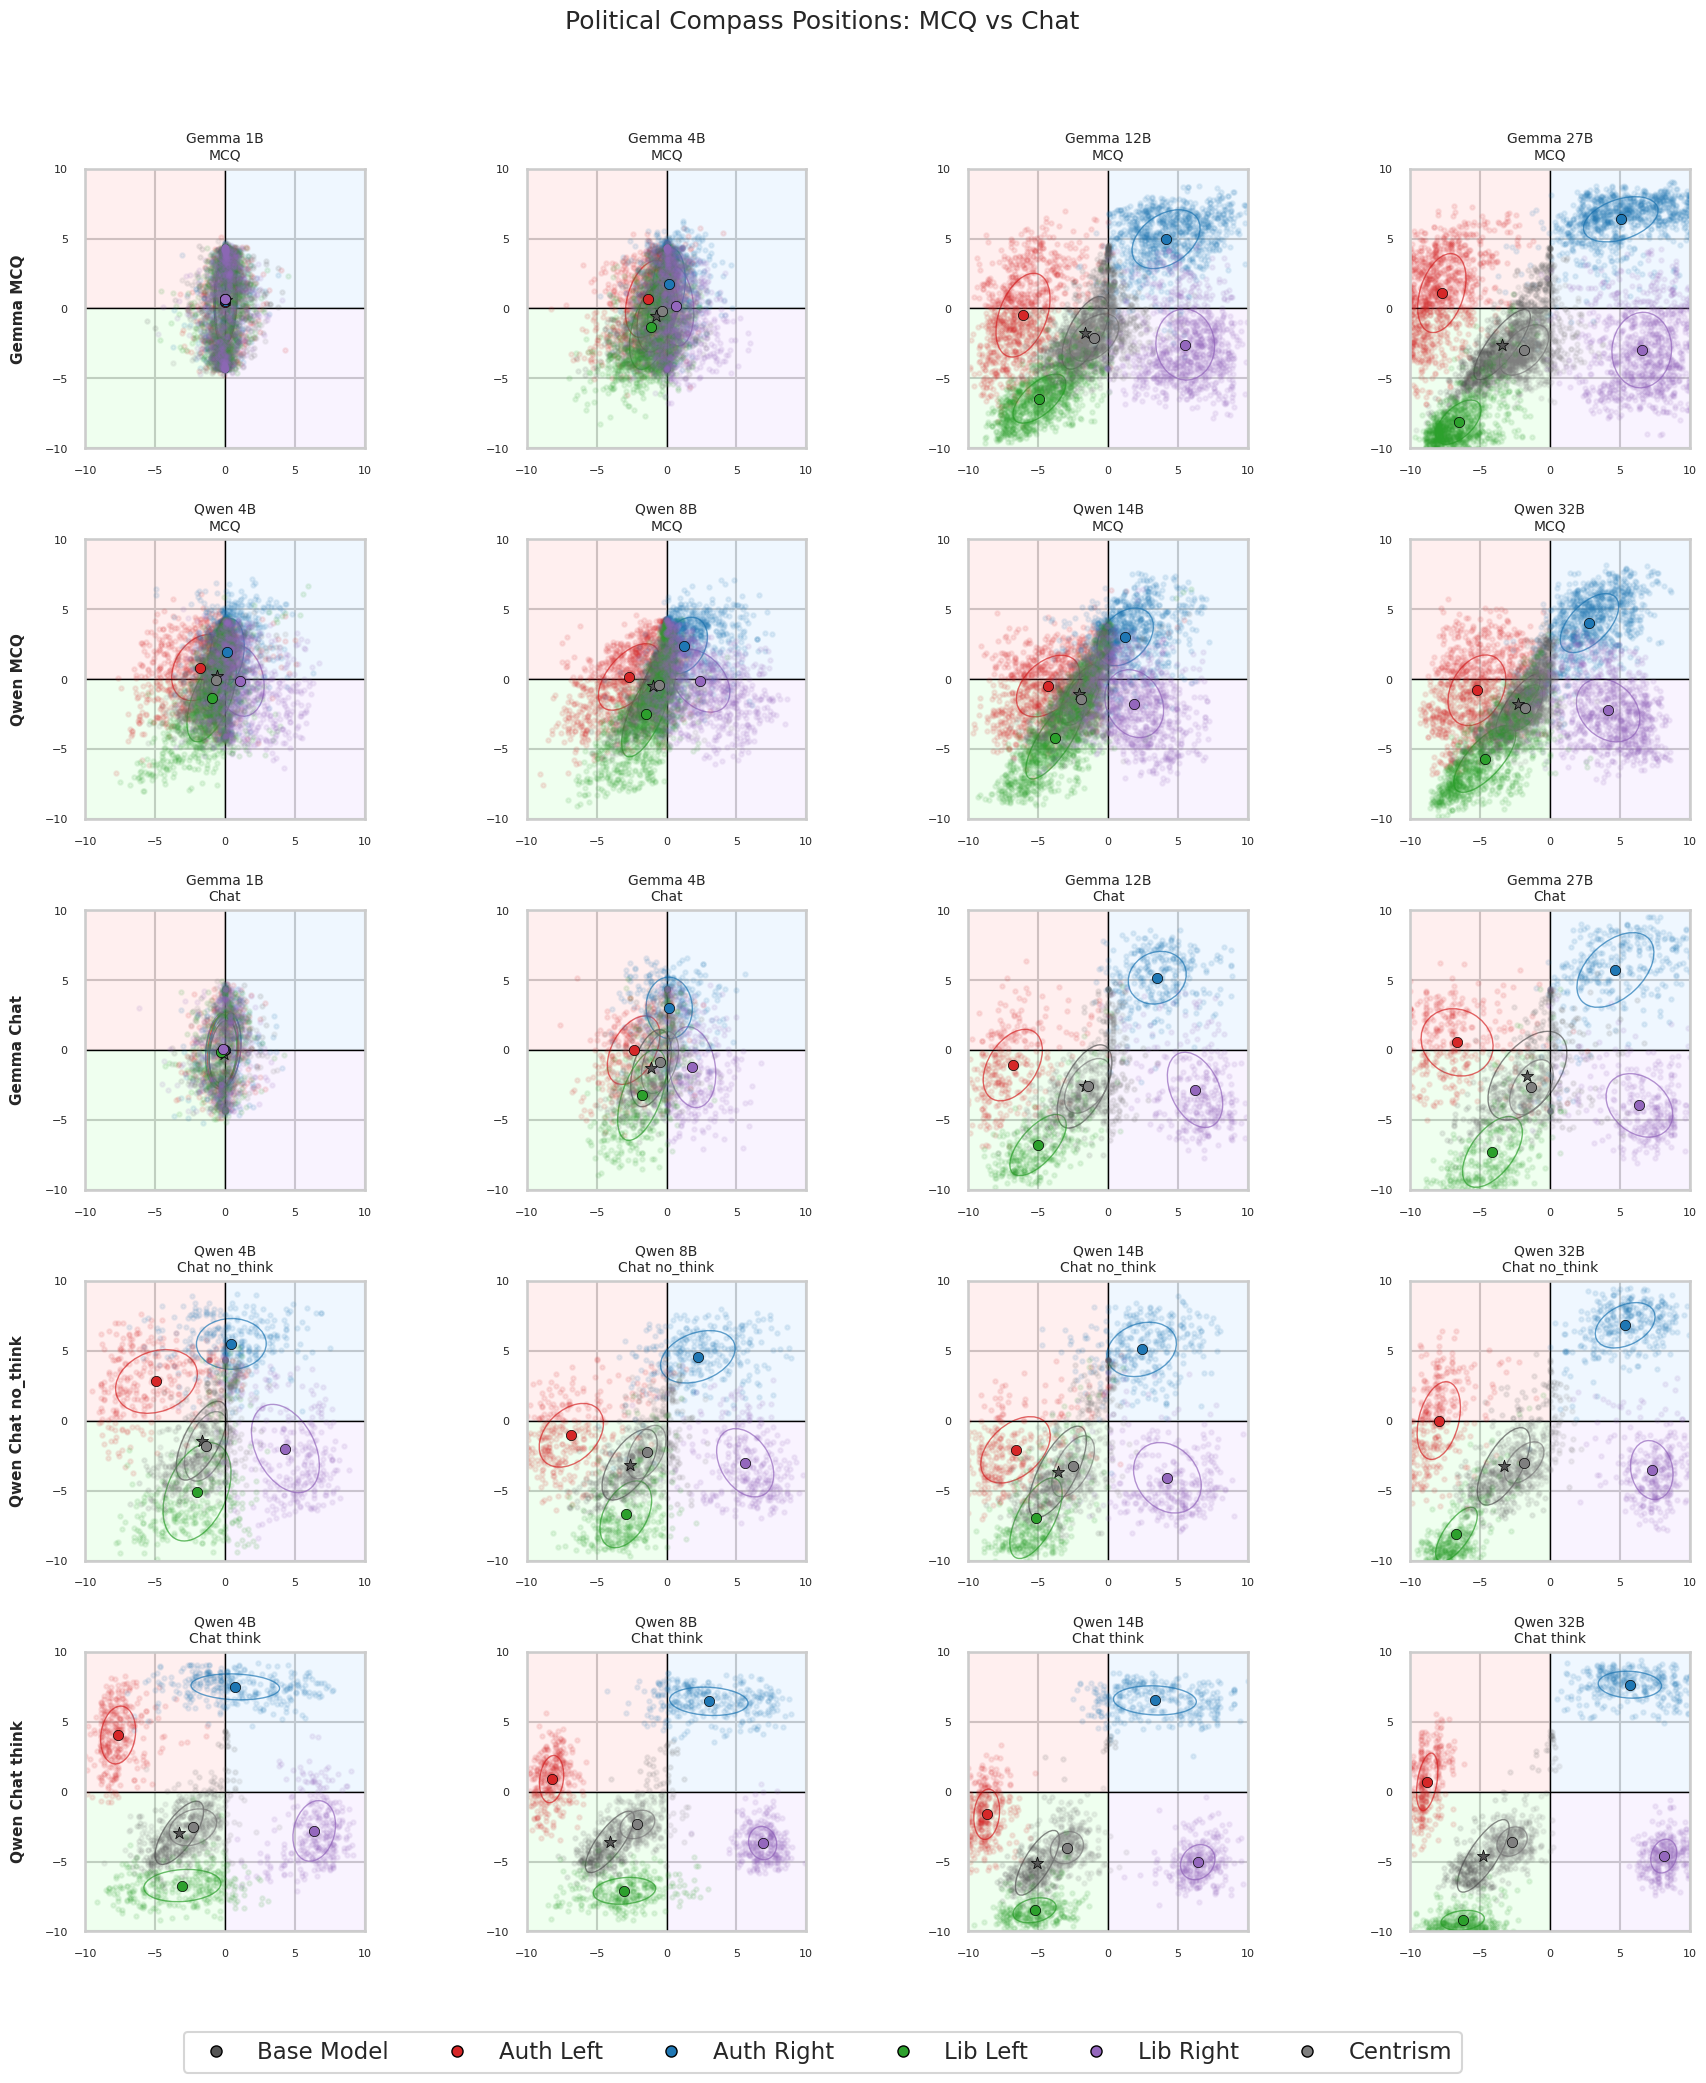

In [5]:
summary_table = (
    combined_df.groupby(["unified_model", "source", "method_label", "ideology"], observed=True)
    .agg(
        econ_mean=("score_econ", "mean"),
        econ_sd=("score_econ", "std"),
        soc_mean=("score_soc", "mean"),
        soc_sd=("score_soc", "std"),
        n_configs=("config_id", "count"),
    )
    .reset_index()
)
summary_table.to_csv(TABLES_DIR / "combined_summary_table.csv", index=False)


def build_row_specs():
    return [
        ("Gemma MCQ", [unified_model_label(model_name, "mcq", "mcq") for model_name in GEMMA_MODELS]),
        ("Qwen MCQ", [unified_model_label(model_name, "mcq", "mcq") for model_name in QWEN_MODELS]),
        ("Gemma Chat", [unified_model_label(model_name, "chat", "standard") for model_name in GEMMA_MODELS]),
        ("Qwen Chat no_think", [unified_model_label(model_name, "chat", "no_think") for model_name in QWEN_MODELS]),
        ("Qwen Chat think", [unified_model_label(model_name, "chat", "think") for model_name in QWEN_MODELS]),
    ]


def plot_compass_rows(df, output_path):
    row_specs = build_row_specs()
    cols = 4
    fig, axes = plt.subplots(len(row_specs), cols, figsize=(4.8 * cols, 4.2 * len(row_specs)))
    axes = np.atleast_2d(axes)

    available = set(df["unified_model"].astype(str).unique())

    for row_idx, (row_title, model_list) in enumerate(row_specs):
        for col_idx in range(cols):
            ax = axes[row_idx, col_idx]
            model_name = model_list[col_idx]

            if model_name not in available:
                ax.axis("off")
                ax.text(0.5, 0.5, f"Missing\n{compact_unified_title(model_name)}", ha="center", va="center", fontsize=9)
                continue

            draw_background(ax)
            sub_df = df[df["unified_model"].astype(str) == model_name].copy()
            ax.set_title(compact_unified_title(model_name), fontsize=10, pad=7)

            for ideology, ide_df in sub_df.groupby("ideology", observed=True):
                label = DISPLAY_NAMES.get(ideology, ideology)
                color = IDEOLOGY_COLORS.get(label, "#333333")
                ax.scatter(
                    ide_df["score_econ"],
                    ide_df["score_soc"],
                    s=10,
                    alpha=0.10,
                    color=color,
                    zorder=2,
                )
                ax.scatter(
                    ide_df["score_econ"].mean(),
                    ide_df["score_soc"].mean(),
                    s=85 if label == "Base Model" else 55,
                    marker="*" if label == "Base Model" else "o",
                    color=color,
                    edgecolor="black",
                    linewidth=0.5,
                    zorder=4,
                )
                confidence_ellipse(
                    ide_df["score_econ"],
                    ide_df["score_soc"],
                    ax,
                    n_std=1.0,
                    edgecolor=color,
                    linewidth=1.0,
                    alpha=0.7,
                )

            if col_idx == 0:
                ax.annotate(
                    row_title,
                    xy=(-0.24, 0.5),
                    xycoords="axes fraction",
                    fontsize=11,
                    fontweight="bold",
                    rotation=90,
                    va="center",
                    ha="center",
                )

    legend_handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=color,
            markeredgecolor="black",
            markersize=8,
            label=label,
        )
        for label, color in IDEOLOGY_COLORS.items()
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=6,
        bbox_to_anchor=(0.5, 0.008),
        frameon=True,
    )
    fig.suptitle("Political Compass Positions: MCQ vs Chat", fontsize=18, y=0.996)
    plt.tight_layout(rect=[0.04, 0.055, 1, 0.975])
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()


plot_compass_rows(combined_df, PLOTS_DIR / "01_political_compass_positions_mcq_chat.png")

In [6]:
def between_group_ss(sub_df, factor, target_col):
    grouped = sub_df.groupby(factor, dropna=False)[target_col]
    means = grouped.mean()
    counts = grouped.count()
    grand_mean = sub_df[target_col].mean()
    ss = float(((means - grand_mean) ** 2 * counts).sum())
    if not np.isfinite(ss):
        return 0.0
    return max(ss, 0.0)


def anova_residual_rmse(sub_df, target_col, applicable_factor_cols):
    # Fit additive OLS with all applicable factors via pd.get_dummies + np.linalg.lstsq.
    # Returns the root mean squared error of residuals.
    predictors = [
        f for f in applicable_factor_cols
        if f in sub_df.columns and sub_df[f].nunique(dropna=False) >= 2
    ]
    if not predictors or len(sub_df) < 5:
        return np.nan

    tmp = sub_df[[target_col] + predictors].copy().dropna(subset=[target_col])
    if len(tmp) < 5:
        return np.nan

    y = tmp[target_col].to_numpy(dtype=float)
    for col in predictors:
        tmp[col] = tmp[col].astype(str)

    try:
        X = pd.get_dummies(tmp[predictors], drop_first=True, dtype=float)
        X.insert(0, "_intercept_", 1.0)
        X_arr = X.to_numpy(dtype=float)

        # Check rank: need more rows than columns
        if X_arr.shape[0] <= X_arr.shape[1]:
            return np.nan

        coeffs, residuals_ss, rank, sv = np.linalg.lstsq(X_arr, y, rcond=None)
        fitted = X_arr @ coeffs
        resid = y - fitted
        df_resid = max(len(y) - rank, 1)
        rmse = float(np.sqrt(np.sum(resid ** 2) / df_resid))
        return rmse
    except Exception:
        return np.nan


def analyze_factor_sensitivity(df, target_col):
    records = []
    for unified_model, sub_df in df.groupby("unified_model", observed=True, sort=False):
        if sub_df.empty:
            continue

        source = sub_df["source"].mode().iat[0]
        applicable_factors = APPLICABLE_FACTORS_BY_SOURCE[source]
        total_n = len(sub_df)

        # Total Variation SD
        total_var_sd = float(sub_df[target_col].std())

        # Residual variance (ANOVA residual RMSE)
        residual_var = anova_residual_rmse(sub_df, target_col, list(applicable_factors))
        intrinsic_col = "row_intrinsic_var_econ" if target_col == "score_econ" else "row_intrinsic_var_soc"

        row = {
            "unified_model": str(unified_model),
            "family": sub_df["family"].mode().iat[0],
            "dimension": target_col,
            "Ideology SD": float(sub_df.groupby("ideology")[target_col].mean().std()),
            "Total Var SD": total_var_sd,
            "Residual variance": residual_var,
            "Logit distribution variance": float(np.sqrt(np.maximum(sub_df[intrinsic_col].sum(), 0.0) / total_n)),
        }

        for factor, label in FACTOR_LABELS.items():
            if factor not in applicable_factors:
                row[label] = np.nan
                continue

            ss_factor = 0.0
            for _, ide_sub in sub_df.groupby("ideology", observed=True):
                if ide_sub[factor].nunique(dropna=False) < 2:
                    continue
                ss_factor += between_group_ss(ide_sub, factor, target_col)

            row[label] = float(np.sqrt(ss_factor / total_n)) if total_n > 0 else np.nan

        records.append(row)

    out = pd.DataFrame(records)
    out["unified_model"] = pd.Categorical(
        out["unified_model"], categories=UNIFIED_MODEL_ORDER, ordered=True
    )
    return out.sort_values("unified_model").reset_index(drop=True)


sensitivity_econ = analyze_factor_sensitivity(combined_df, "score_econ")
sensitivity_soc = analyze_factor_sensitivity(combined_df, "score_soc")

sensitivity_long = pd.concat([sensitivity_econ, sensitivity_soc], ignore_index=True)
sensitivity_long.to_csv(TABLES_DIR / "combined_factor_sensitivity.csv", index=False)

print("Factor sensitivity computed.")
print(f"Econ rows: {len(sensitivity_econ)}, Soc rows: {len(sensitivity_soc)}")
display(sensitivity_econ.head(4))

Factor sensitivity computed.
Econ rows: 20, Soc rows: 20


,unified_model,family,dimension,Ideology SD,Total Var SD,Residual variance,Logit distribution variance,Quantization,Language,Context,Instruction,Reasoning Mode,Suffix,Key Type,Permutation,Persona
0,Gemma 1B MCQ,Gemma-3,score_econ,0.022483,0.756766,0.740756,1.085187,0.048521,0.116670,0.073701,0.111399,NaN,NaN,0.077380,0.093725,0.082588
1,Gemma 1B Chat,Gemma-3,score_econ,0.091594,1.122650,1.092684,0.528655,NaN,NaN,0.160026,0.202993,0.147795,0.112223,0.154218,0.164921,0.182685
2,Gemma 4B MCQ,Gemma-3,score_econ,0.760179,1.524139,1.454718,0.964696,0.122023,0.406485,0.360065,0.341788,NaN,NaN,0.113319,0.180497,0.300048
3,Gemma 4B Chat,Gemma-3,score_econ,1.497262,2.130312,2.081973,0.438774,NaN,NaN,0.417942,0.444597,0.281984,0.261891,0.155001,0.354681,0.510241


## Factor-Sensitivity Heatmap Layout Note

The family brackets in `02a_factor_sensitivity_economic` and `02b_factor_sensitivity_social` are drawn in figure coordinates after the heatmap axes are laid out. The earlier layout did not reserve enough left margin, so the Gemma-3 and Qwen3 brackets were placed inside the model row-label band. The plotting helper below reserves a larger left margin and moves the bracket/tick coordinates further left, keeping the group labels visually separate from the row labels.

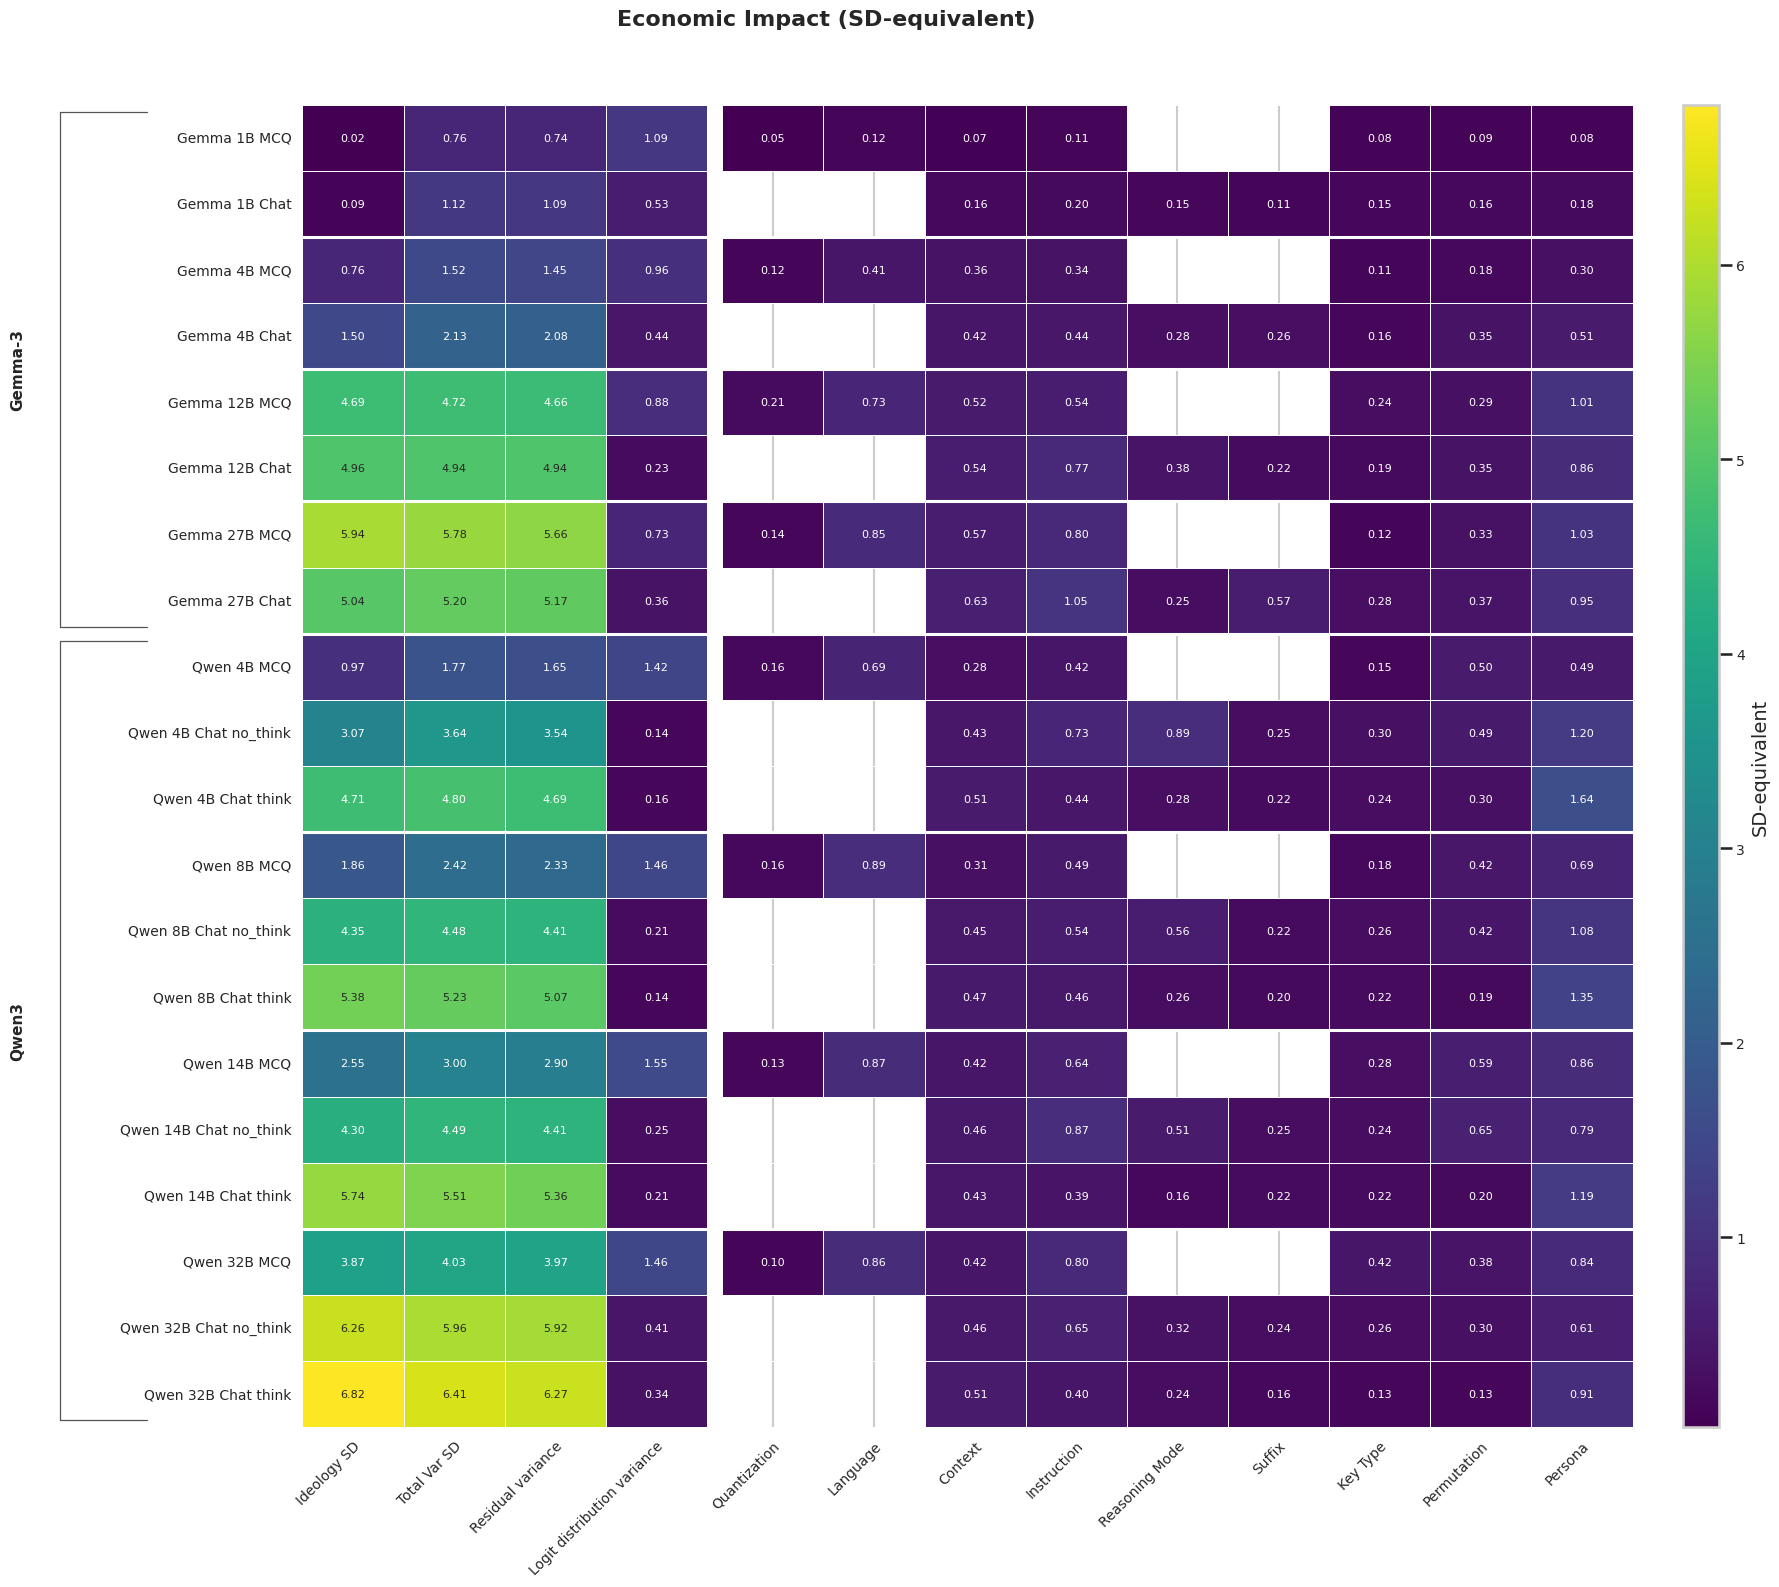

In [7]:
def plot_single_heatmap(sensitivity_df, dim_title, output_path):
    row_order = UNIFIED_MODEL_ORDER[:]
    sensitivity_df = sensitivity_df.set_index("unified_model").reindex(row_order).reset_index()

    group_a = ["Ideology SD", "Total Var SD", "Residual variance", "Logit distribution variance"]
    group_b = [
        "Quantization",
        "Language",
        "Context",
        "Instruction",
        "Reasoning Mode",
        "Suffix",
        "Key Type",
        "Permutation",
        "Persona",
    ]

    all_values = sensitivity_df[group_a + group_b].to_numpy(dtype=float)
    finite_values = all_values[np.isfinite(all_values)]
    vmin = float(np.nanmin(finite_values)) if finite_values.size else 0.0
    vmax = float(np.nanmax(finite_values)) if finite_values.size else 1.0

    font_tick = 10
    font_annot = 8
    font_label = 14

    n_a = len(group_a)
    n_b = len(group_b)
    width_ratios = [n_a, 0.15, n_b, 0.5, 0.35]
    fig_w = sum(width_ratios) * 1.1 + 4
    fig_h = max(14, len(row_order) * 0.62 + 5)
    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = gridspec.GridSpec(1, 5, width_ratios=width_ratios, wspace=0.0)
    # Reserve explicit left margin for model row labels plus the family bracket.
    # The previous version placed the bracket only slightly left of the heatmap
    # axes, which put the Gemma-3/Qwen3 group markers inside the row-label band.
    fig.subplots_adjust(left=0.23, right=0.96, top=0.94, bottom=0.18)

    ax_a = fig.add_subplot(gs[0])
    ax_gap = fig.add_subplot(gs[1])
    ax_b = fig.add_subplot(gs[2])
    ax_cb = fig.add_subplot(gs[4])
    ax_gap.set_visible(False)

    hm_kw = dict(
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        fmt="",
        annot_kws={"size": font_annot},
        linewidths=0.5,
        linecolor="white",
    )

    def create_annot(df, columns):
        annot = df.set_index("unified_model")[columns].copy()
        for column in annot.columns:
            annot[column] = annot[column].map(lambda value: "" if pd.isna(value) else f"{value:.2f}")
        return annot

    def draw_heatmap(ax, df, columns, show_yticks):
        values = df.set_index("unified_model")[columns]
        mask = values.isna()
        yticklabels = row_order if show_yticks else False
        sns.heatmap(
            values,
            mask=mask,
            annot=create_annot(df, columns),
            ax=ax,
            yticklabels=yticklabels,
            **hm_kw,
        )
        if show_yticks:
            ax.set_yticklabels(row_order, fontsize=font_tick)
        else:
            ax.set_yticks([])
        ax.set_xticklabels(columns, rotation=45, ha="right", fontsize=font_tick, rotation_mode="anchor")
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(length=0, pad=8)

    draw_heatmap(ax_a, sensitivity_df, group_a, show_yticks=True)
    draw_heatmap(ax_b, sensitivity_df, group_b, show_yticks=False)

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    scalar_mappable = mpl.cm.ScalarMappable(cmap="viridis", norm=norm)
    scalar_mappable.set_array([])
    colorbar = fig.colorbar(scalar_mappable, cax=ax_cb)
    colorbar.set_label("SD-equivalent", fontsize=font_label)
    colorbar.ax.tick_params(labelsize=font_tick)

    # Size-block separators
    block_keys = [" ".join(str(label).split(" ")[:2]) for label in row_order]
    for row_idx in range(1, len(block_keys)):
        if block_keys[row_idx] != block_keys[row_idx - 1]:
            for axis in [ax_a, ax_b]:
                axis.axhline(row_idx, color="white", lw=2.2)

    # Family brackets
    fam_label_map = {"Gemma": "Gemma-3", "Qwen": "Qwen3"}
    family_tags = [fam_label_map.get(str(label).split(" ")[0], "Other") for label in row_order]
    spans = []
    start = 0
    while start < len(family_tags):
        end = start
        while end < len(family_tags) and family_tags[end] == family_tags[start]:
            end += 1
        spans.append((family_tags[start], start, end - 1))
        start = end

    fig.canvas.draw()
    ax_pos = ax_a.get_position()
    row_height = (ax_pos.y1 - ax_pos.y0) / max(len(row_order), 1)
    bracket_x = ax_pos.x0 - 0.125
    tick_x = ax_pos.x0 - 0.080

    for family_name, row_start, row_end in spans:
        y_top = ax_pos.y1 - row_start * row_height
        y_bottom = ax_pos.y1 - (row_end + 1) * row_height
        y_mid = (y_top + y_bottom) / 2

        fig.text(
            bracket_x - 0.018,
            y_mid,
            family_name,
            ha="right",
            va="center",
            rotation=90,
            fontsize=font_tick + 1,
            fontweight="bold",
            transform=fig.transFigure,
        )

        fig.add_artist(
            plt.Line2D(
                [bracket_x, bracket_x],
                [y_bottom + 0.004, y_top - 0.004],
                transform=fig.transFigure,
                color="#555555",
                lw=0.9,
                clip_on=False,
            )
        )
        for y_edge in [y_top - 0.004, y_bottom + 0.004]:
            fig.add_artist(
                plt.Line2D(
                    [bracket_x, tick_x],
                    [y_edge, y_edge],
                    transform=fig.transFigure,
                    color="#555555",
                    lw=0.9,
                    clip_on=False,
                )
            )

    fig.suptitle(f"{dim_title} Impact (SD-equivalent)", fontsize=font_label + 2, fontweight="bold", y=0.995)
    plt.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()


plot_single_heatmap(
    sensitivity_econ,
    "Economic",
    PLOTS_DIR / "02a_factor_sensitivity_economic.png",
)

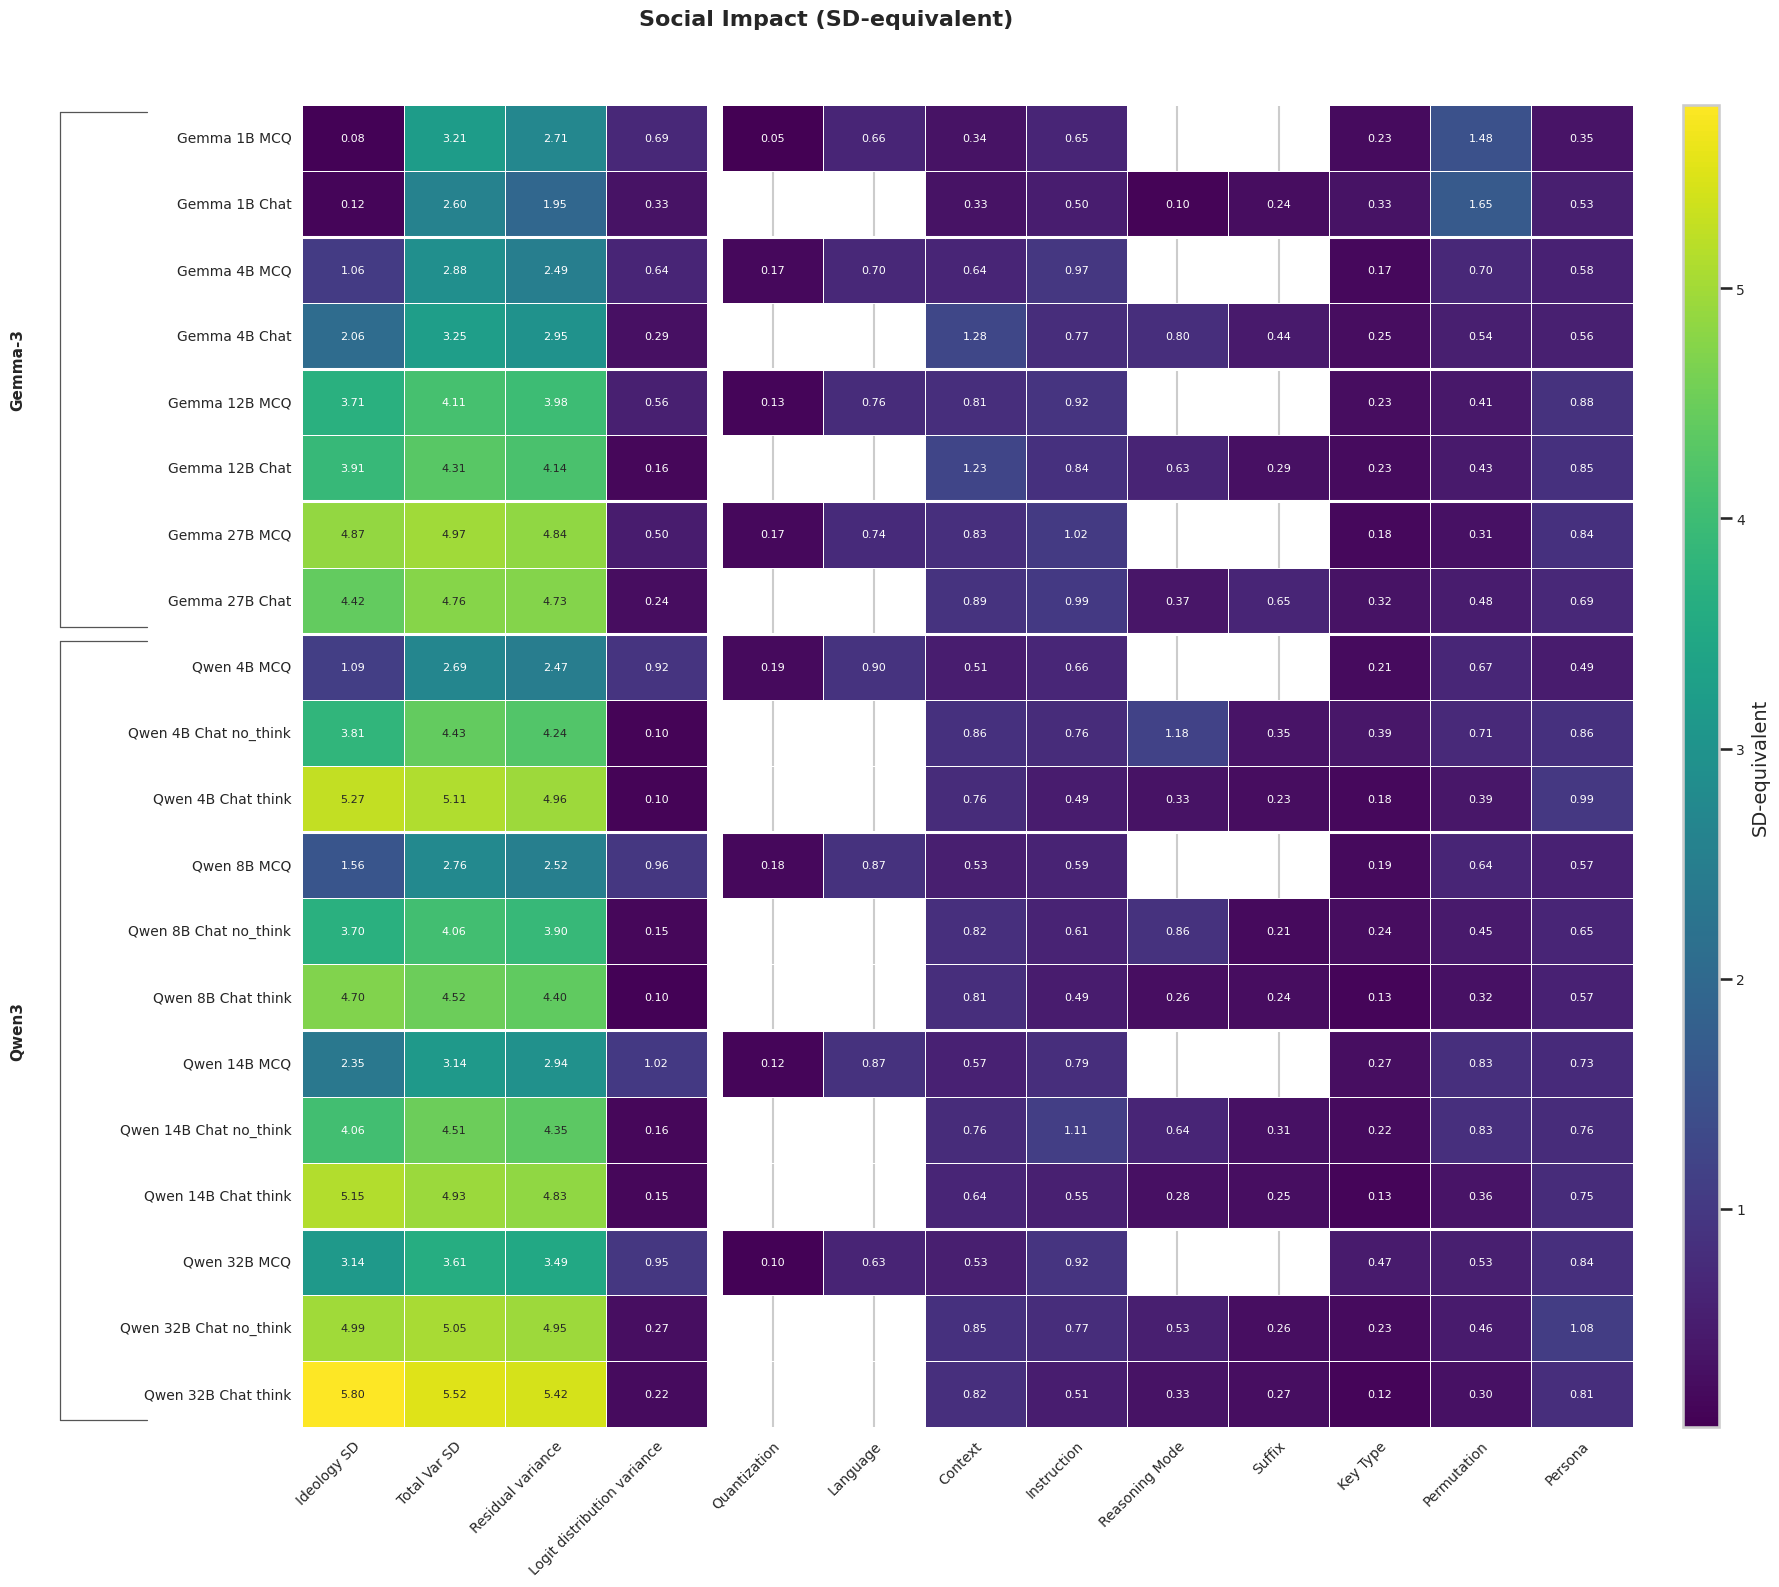

In [8]:
plot_single_heatmap(
    sensitivity_soc,
    "Social",
    PLOTS_DIR / "02b_factor_sensitivity_social.png",
)

In [9]:
shared_key_cols = [
    "base_model",
    "ideology",
    "context_combo",
    "instr_combo",
    "persona_combo",
    "key_type",
    "perm_id",
]

mcq_reference = combined_df[
    (combined_df["source"] == "mcq")
    & (combined_df["quantization"] == MCQ_REFERENCE_QUANT)
    & (combined_df["language"] == MCQ_REFERENCE_LANGUAGE)
].copy()

chat_reference = combined_df[combined_df["source"] == "chat"].copy()

# ── Group "Standard Chat" = Gemma Chat + Qwen Chat no_think ─────────────────
# These are functionally equivalent: free-text generation without explicit
# reasoning chains. Grouping them gives a cleaner contrast against MCQ.
chat_reference["chat_group"] = chat_reference["method_label"].map({
    "Chat": "Standard Chat",
    "Chat no_think": "Standard Chat",
    "Chat think": "Chat Think",
})

def mean_overlap(df, key_cols):
    if df.empty:
        return pd.DataFrame(columns=key_cols + ["score_econ", "score_soc"])
    return (
        df.groupby(key_cols, dropna=False)[["score_econ", "score_soc"]]
        .mean()
        .reset_index()
    )


mcq_overlap = mean_overlap(mcq_reference, shared_key_cols)
all_chat_overlap = mean_overlap(chat_reference, shared_key_cols)
standard_chat_overlap = mean_overlap(
    chat_reference[chat_reference["chat_group"] == "Standard Chat"],
    shared_key_cols,
)
think_chat_overlap = mean_overlap(
    chat_reference[chat_reference["chat_group"] == "Chat Think"],
    shared_key_cols,
)

overlap_frames = []


def append_overlap(left_df, right_df, comparison_name, left_label, right_label):
    merged = left_df.merge(
        right_df,
        on=shared_key_cols,
        how="inner",
        suffixes=("_chat", "_mcq"),
    )
    if merged.empty:
        return
    merged["comparison"] = comparison_name
    merged["left_label"] = left_label
    merged["right_label"] = right_label
    overlap_frames.append(merged)


# Comparison A: MCQ vs Chat (All chat variants collapsed)
append_overlap(
    all_chat_overlap,
    mcq_overlap,
    "MCQ vs Chat (All)",
    "Chat (all)",
    "MCQ",
)

# Comparison B: MCQ vs Standard Chat (Gemma Chat + Qwen no_think)
append_overlap(
    standard_chat_overlap,
    mcq_overlap,
    "MCQ vs Standard Chat",
    "Standard Chat",
    "MCQ",
)

# Comparison C: MCQ vs Chat Think (Qwen-only by construction)
append_overlap(
    think_chat_overlap,
    mcq_overlap,
    "MCQ vs Chat Think",
    "Chat Think",
    "MCQ",
)

# Comparison D: Standard Chat vs Chat Think (Qwen only)
qwen_standard = standard_chat_overlap[standard_chat_overlap["base_model"].isin(QWEN_MODELS)]
qwen_think = think_chat_overlap[think_chat_overlap["base_model"].isin(QWEN_MODELS)]
append_overlap(
    qwen_standard,
    qwen_think,
    "Standard Chat vs Chat Think",
    "Standard Chat",
    "Chat Think",
)

mcq_chat_overlap = pd.concat(overlap_frames, ignore_index=True) if overlap_frames else pd.DataFrame()

if not mcq_chat_overlap.empty:
    missing_base = int(mcq_chat_overlap["base_model"].isna().sum())
    if missing_base > 0:
        print(f"Warning: dropping {missing_base} overlap rows with NaN base_model.")
        mcq_chat_overlap = mcq_chat_overlap[mcq_chat_overlap["base_model"].notna()].copy()

    pair_counts_df = (
        mcq_chat_overlap.groupby(["comparison", "base_model"], dropna=False)
        .size()
        .reset_index(name="n_pairs")
        .sort_values(["comparison", "base_model"])
        .reset_index(drop=True)
    )
    pair_counts_df.to_csv(TABLES_DIR / "mcq_chat_overlap_pair_counts.csv", index=False)

    print(f"Aligned comparison pairs: {len(mcq_chat_overlap)}")
    print("Pairs by comparison:")
    print(mcq_chat_overlap.groupby("comparison", dropna=False).size())
    print("Per-model pair-count summary:")
    print(pair_counts_df.groupby("comparison")["n_pairs"].describe())
    display(pair_counts_df.head(20))
else:
    pair_counts_df = pd.DataFrame(columns=["comparison", "base_model", "n_pairs"])
    print("Aligned comparison pairs: 0")

mcq_chat_overlap.to_csv(TABLES_DIR / "mcq_chat_overlap_pairs.csv", index=False)

Aligned comparison pairs: 7020
Pairs by comparison:
comparison
MCQ vs Chat (All)                96
MCQ vs Chat Think                48
MCQ vs Standard Chat             96
Standard Chat vs Chat Think    6780
dtype: int64
Per-model pair-count summary:
                             count    mean  std     min     25%     50%  \
comparison                                                                
MCQ vs Chat (All)              8.0    12.0  0.0    12.0    12.0    12.0   
MCQ vs Chat Think              4.0    12.0  0.0    12.0    12.0    12.0   
MCQ vs Standard Chat           8.0    12.0  0.0    12.0    12.0    12.0   
Standard Chat vs Chat Think    4.0  1695.0  0.0  1695.0  1695.0  1695.0   

                                75%     max  
comparison                                   
MCQ vs Chat (All)              12.0    12.0  
MCQ vs Chat Think              12.0    12.0  
MCQ vs Standard Chat           12.0    12.0  
Standard Chat vs Chat Think  1695.0  1695.0  


,comparison,base_model,n_pairs
0,MCQ vs Chat (All),Qwen3-14B,12
1,MCQ vs Chat (All),Qwen3-32B,12
2,MCQ vs Chat (All),Qwen3-4B,12
3,MCQ vs Chat (All),Qwen3-8B,12
4,MCQ vs Chat (All),gemma-3-12b-it,12
5,MCQ vs Chat (All),gemma-3-1b-it,12
6,MCQ vs Chat (All),gemma-3-27b-it,12
7,MCQ vs Chat (All),gemma-3-4b-it,12
8,MCQ vs Chat Think,Qwen3-14B,12
9,MCQ vs Chat Think,Qwen3-32B,12


In [10]:
def paired_bayes_bootstrap(x, y, draws=BAYES_DRAWS, rope=BAYES_ROPE, seed=42):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if x.size == 0:
        return {
            "n_pairs": 0,
            "observed_mean_diff": np.nan,
            "posterior_mean_diff": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "p_gt_0": np.nan,
            "p_lt_0": np.nan,
            "p_rope": np.nan,
        }

    diffs = x - y
    rng = np.random.default_rng(seed)
    weights = rng.dirichlet(np.ones(diffs.size), size=draws)
    samples = weights @ diffs

    return {
        "n_pairs": int(diffs.size),
        "observed_mean_diff": float(np.mean(diffs)),
        "posterior_mean_diff": float(np.mean(samples)),
        "ci_low": float(np.quantile(samples, 0.025)),
        "ci_high": float(np.quantile(samples, 0.975)),
        "p_gt_0": float(np.mean(samples > 0)),
        "p_lt_0": float(np.mean(samples < 0)),
        "p_rope": float(np.mean(np.abs(samples) <= rope)),
    }


def try_baycomp_summary(x, y, rope=BAYES_ROPE):
    try:
        import baycomp
    except Exception:
        return {}

    for candidate in ("SignedRankTest", "SignTest"):
        test = getattr(baycomp, candidate, None)
        if test is None:
            continue
        try:
            outcome = test(x, y, rope=rope)
            probs = None
            if isinstance(outcome, tuple) and len(outcome) == 3:
                probs = outcome
            elif hasattr(outcome, "probs"):
                probs = outcome.probs()
            elif callable(outcome):
                maybe_probs = outcome()
                if isinstance(maybe_probs, tuple) and len(maybe_probs) == 3:
                    probs = maybe_probs
            if probs is not None:
                left, rope_p, right = [float(value) for value in probs]
                return {
                    "baycomp_test": candidate,
                    "baycomp_left": left,
                    "baycomp_rope": rope_p,
                    "baycomp_right": right,
                }
        except Exception:
            continue
    return {}


def paired_permutation_pvalue(x, y, n_perm=PERMUTATION_DRAWS, seed=99):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if x.size == 0:
        return np.nan

    diffs = x - y
    observed = float(np.mean(diffs))
    rng = np.random.default_rng(seed)
    signs = rng.choice([-1.0, 1.0], size=(n_perm, diffs.size), replace=True)
    perm_means = (signs * diffs).mean(axis=1)
    exceedances = int(np.sum(np.abs(perm_means) >= abs(observed)))
    # Plus-one correction avoids reporting exact zero from a finite Monte Carlo test.
    p_value = float((exceedances + 1) / (n_perm + 1))
    return p_value


def paired_effect_size_dz(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    diffs = x[mask] - y[mask]
    if diffs.size < 2:
        return np.nan
    sd = float(np.std(diffs, ddof=1))
    if sd <= 0:
        return np.nan
    return float(np.mean(diffs) / sd)


def paired_robust_summary(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if x.size == 0:
        return {
            "n_pairs": 0,
            "mean_diff": np.nan,
            "median_diff": np.nan,
            "effect_size_dz": np.nan,
            "perm_p_value": np.nan,
            "wasserstein": np.nan,
        }

    diffs = x - y
    return {
        "n_pairs": int(diffs.size),
        "mean_diff": float(np.mean(diffs)),
        "median_diff": float(np.median(diffs)),
        "effect_size_dz": paired_effect_size_dz(x, y),
        "perm_p_value": paired_permutation_pvalue(x, y),
        "wasserstein": float(wasserstein_distance(x, y)),
    }


def cluster_bootstrap_mean_diff(pair_df, left_col, right_col, cluster_col="base_model", draws=6000, seed=202):
    tmp = pair_df[[cluster_col, left_col, right_col]].copy()
    tmp[left_col] = pd.to_numeric(tmp[left_col], errors="coerce")
    tmp[right_col] = pd.to_numeric(tmp[right_col], errors="coerce")
    tmp = tmp.dropna(subset=[cluster_col, left_col, right_col])
    if tmp.empty:
        return {
            "n_pairs": 0,
            "n_clusters": 0,
            "observed_mean_diff": np.nan,
            "cluster_ci_low": np.nan,
            "cluster_ci_high": np.nan,
        }

    clusters = tmp[cluster_col].astype(str).unique()
    diffs_by_cluster = {
        cluster: (cluster_df[left_col].to_numpy(dtype=float) - cluster_df[right_col].to_numpy(dtype=float))
        for cluster, cluster_df in tmp.groupby(cluster_col, observed=True)
    }
    observed = float((tmp[left_col] - tmp[right_col]).mean())
    rng = np.random.default_rng(seed)
    samples = np.empty(draws, dtype=float)
    for draw_idx in range(draws):
        sampled_clusters = rng.choice(clusters, size=len(clusters), replace=True)
        sampled_diffs = np.concatenate([diffs_by_cluster[cluster] for cluster in sampled_clusters])
        samples[draw_idx] = float(np.mean(sampled_diffs))

    return {
        "n_pairs": int(len(tmp)),
        "n_clusters": int(len(clusters)),
        "observed_mean_diff": observed,
        "cluster_ci_low": float(np.quantile(samples, 0.025)),
        "cluster_ci_high": float(np.quantile(samples, 0.975)),
    }


def _run_comparison_worker(args):
    comparison_name, base_model, dim_name, x_vals, y_vals, seed, left_label, right_label = args
    bayes = paired_bayes_bootstrap(x_vals, y_vals, seed=seed)
    bayes.update(
        {
            "comparison": comparison_name,
            "base_model": base_model,
            "dimension": dim_name,
            "left_label": left_label,
            "right_label": right_label,
            "delta_definition": f"{left_label} - {right_label}",
        }
    )
    bayes.update(try_baycomp_summary(x_vals, y_vals))

    robust = paired_robust_summary(x_vals, y_vals)
    robust.update(
        {
            "comparison": comparison_name,
            "base_model": base_model,
            "dimension": dim_name,
            "left_label": left_label,
            "right_label": right_label,
            "delta_definition": f"{left_label} - {right_label}",
        }
    )
    return bayes, robust


def ensure_result_columns(df):
    expected_cols = [
        "comparison",
        "base_model",
        "dimension",
        "left_label",
        "right_label",
        "delta_definition",
        "n_pairs",
        "observed_mean_diff",
        "posterior_mean_diff",
        "ci_low",
        "ci_high",
        "p_gt_0",
        "p_lt_0",
        "p_rope",
        "baycomp_test",
        "baycomp_left",
        "baycomp_rope",
        "baycomp_right",
        "mean_diff",
        "median_diff",
        "effect_size_dz",
        "perm_p_value",
        "wasserstein",
    ]
    out = df.copy()
    for col in expected_cols:
        if col not in out.columns:
            out[col] = np.nan
    return out


# Build work items
print(f"Bayesian ROPE interval: [-{BAYES_ROPE:.2f}, +{BAYES_ROPE:.2f}]")

mcq_chat_tasks = []
if not mcq_chat_overlap.empty:
    # Overall comparisons
    for comparison_name, sub_df in mcq_chat_overlap.groupby("comparison", observed=True):
        left_label = str(sub_df["left_label"].iloc[0]) if "left_label" in sub_df.columns else "Left"
        right_label = str(sub_df["right_label"].iloc[0]) if "right_label" in sub_df.columns else "Right"
        for dim_name, chat_col, mcq_col in [
            ("Economic", "score_econ_chat", "score_econ_mcq"),
            ("Social", "score_soc_chat", "score_soc_mcq"),
        ]:
            mcq_chat_tasks.append((
                comparison_name, "Overall", dim_name,
                sub_df[chat_col].to_numpy(), sub_df[mcq_col].to_numpy(), 42,
                left_label, right_label,
            ))

    # Per-model comparisons
    for (comparison_name, base_model), sub_df in mcq_chat_overlap.groupby(["comparison", "base_model"], observed=True):
        left_label = str(sub_df["left_label"].iloc[0]) if "left_label" in sub_df.columns else "Left"
        right_label = str(sub_df["right_label"].iloc[0]) if "right_label" in sub_df.columns else "Right"
        for dim_name, chat_col, mcq_col in [
            ("Economic", "score_econ_chat", "score_econ_mcq"),
            ("Social", "score_soc_chat", "score_soc_mcq"),
        ]:
            mcq_chat_tasks.append((
                comparison_name, base_model, dim_name,
                sub_df[chat_col].to_numpy(), sub_df[mcq_col].to_numpy(), 123,
                left_label, right_label,
            ))

print(f"MCQ vs Chat comparison tasks: {len(mcq_chat_tasks)}")

mcq_chat_all_bayes = []
mcq_chat_all_robust = []
if mcq_chat_tasks:
    with ProcessPoolExecutor(max_workers=N_WORKERS) as executor:
        futures = {executor.submit(_run_comparison_worker, t): t for t in mcq_chat_tasks}
        for future in as_completed(futures):
            bayes, robust = future.result()
            mcq_chat_all_bayes.append(bayes)
            mcq_chat_all_robust.append(robust)

mcq_chat_all_bayes_df = ensure_result_columns(pd.DataFrame(mcq_chat_all_bayes))
mcq_chat_all_robust_df = ensure_result_columns(pd.DataFrame(mcq_chat_all_robust))

for frame in [mcq_chat_all_bayes_df, mcq_chat_all_robust_df]:
    frame["base_model"] = frame["base_model"].fillna("Unknown").astype(str)

# Split overall vs per-model
mcq_chat_bayes_df = mcq_chat_all_bayes_df[mcq_chat_all_bayes_df["base_model"] == "Overall"].copy()
mcq_chat_robust_df = mcq_chat_all_robust_df[mcq_chat_all_robust_df["base_model"] == "Overall"].copy()
mcq_chat_model_bayes_df = mcq_chat_all_bayes_df[mcq_chat_all_bayes_df["base_model"] != "Overall"].copy()
mcq_chat_model_robust_df = mcq_chat_all_robust_df[mcq_chat_all_robust_df["base_model"] != "Overall"].copy()

mcq_chat_robust_df = add_bh_qvalues(mcq_chat_robust_df)
mcq_chat_model_robust_df = add_bh_qvalues(mcq_chat_model_robust_df)
for frame in [mcq_chat_robust_df, mcq_chat_model_robust_df]:
    frame["p_value_display"] = frame["perm_p_value"].map(p_value_label)

bayes_cols = [
    "comparison",
    "base_model",
    "dimension",
    "left_label",
    "right_label",
    "delta_definition",
    "n_pairs",
    "observed_mean_diff",
    "posterior_mean_diff",
    "ci_low",
    "ci_high",
    "p_gt_0",
    "p_lt_0",
    "p_rope",
    "baycomp_test",
    "baycomp_left",
    "baycomp_rope",
    "baycomp_right",
]
robust_cols = [
    "comparison",
    "base_model",
    "dimension",
    "left_label",
    "right_label",
    "delta_definition",
    "n_pairs",
    "mean_diff",
    "median_diff",
    "effect_size_dz",
    "perm_p_value",
    "p_value_display",
    "q_value_bh",
    "significant_bh_05",
    "wasserstein",
]

mcq_chat_bayes_df = mcq_chat_bayes_df[bayes_cols].copy()
mcq_chat_robust_df = mcq_chat_robust_df[robust_cols].copy()
mcq_chat_model_bayes_df = mcq_chat_model_bayes_df[bayes_cols].copy()
mcq_chat_model_robust_df = mcq_chat_model_robust_df[robust_cols].copy()

mcq_chat_bayes_df.to_csv(TABLES_DIR / "mcq_vs_chat_bayesian_summary.csv", index=False)
mcq_chat_robust_df.to_csv(TABLES_DIR / "mcq_vs_chat_robust_summary.csv", index=False)
mcq_chat_model_bayes_df.to_csv(TABLES_DIR / "mcq_vs_chat_bayesian_by_model.csv", index=False)
mcq_chat_model_robust_df.to_csv(TABLES_DIR / "mcq_vs_chat_robust_by_model.csv", index=False)

cluster_rows = []
if not mcq_chat_overlap.empty:
    for comparison_name, sub_df in mcq_chat_overlap.groupby("comparison", observed=True):
        left_label = str(sub_df["left_label"].iloc[0])
        right_label = str(sub_df["right_label"].iloc[0])
        for dim_name, left_col, right_col in [
            ("Economic", "score_econ_chat", "score_econ_mcq"),
            ("Social", "score_soc_chat", "score_soc_mcq"),
        ]:
            stats = cluster_bootstrap_mean_diff(sub_df, left_col, right_col, cluster_col="base_model")
            stats.update(
                {
                    "comparison": comparison_name,
                    "dimension": dim_name,
                    "left_label": left_label,
                    "right_label": right_label,
                    "delta_definition": f"{left_label} - {right_label}",
                }
            )
            cluster_rows.append(stats)

mcq_chat_cluster_df = pd.DataFrame(cluster_rows)
mcq_chat_cluster_df.to_csv(TABLES_DIR / "mcq_vs_chat_cluster_bootstrap_by_model.csv", index=False)

if mcq_chat_bayes_df["baycomp_test"].isna().all():
    print("Note: baycomp unavailable; baycomp probability columns are NaN.")

print("Aligned comparisons — Bayesian summary (overall):")
display(mcq_chat_bayes_df)
print("\nAligned comparisons — robust summary (overall):")
display(mcq_chat_robust_df)
print("\nAligned comparisons — model-cluster bootstrap CI (overall):")
display(mcq_chat_cluster_df)
print("\nAligned comparisons — Bayesian by model:")
display(mcq_chat_model_bayes_df)

Bayesian ROPE interval: [-0.25, +0.25]
MCQ vs Chat comparison tasks: 56
Aligned comparisons — Bayesian summary (overall):


,comparison,base_model,dimension,left_label,right_label,delta_definition,n_pairs,observed_mean_diff,posterior_mean_diff,ci_low,ci_high,p_gt_0,p_lt_0,p_rope,baycomp_test,baycomp_left,baycomp_rope,baycomp_right
0,MCQ vs Chat Think,Overall,Economic,Chat Think,MCQ,Chat Think - MCQ,48,-1.909941,-1.913929,-2.726247,-0.985409,0.00000,1.00000,0.00045,SignedRankTest,0.00012,0.0,0.99988
1,MCQ vs Chat Think,Overall,Social,Chat Think,MCQ,Chat Think - MCQ,48,-1.539170,-1.542591,-2.359604,-0.650471,0.00055,0.99945,0.00355,SignedRankTest,0.00026,0.0,0.99974
4,MCQ vs Chat (All),Overall,Economic,Chat (all),MCQ,Chat (all) - MCQ,96,-0.847107,-0.848464,-1.318582,-0.352707,0.00050,0.99950,0.00985,SignedRankTest,0.00012,0.0,0.99988
5,MCQ vs Standard Chat,Overall,Social,Standard Chat,MCQ,Standard Chat - MCQ,96,-0.721710,-0.725399,-1.391253,-0.030714,0.02050,0.97950,0.08055,SignedRankTest,0.00946,0.0,0.99054
6,MCQ vs Standard Chat,Overall,Economic,Standard Chat,MCQ,Standard Chat - MCQ,96,-0.645465,-0.645280,-1.099956,-0.190353,0.00360,0.99640,0.04485,SignedRankTest,0.00158,0.0,0.99842
7,MCQ vs Chat (All),Overall,Social,Chat (all),MCQ,Chat (all) - MCQ,96,-0.813974,-0.817754,-1.487814,-0.120611,0.01195,0.98805,0.05045,SignedRankTest,0.00478,0.0,0.99522
54,Standard Chat vs Chat Think,Overall,Social,Standard Chat,Chat Think,Standard Chat - Chat Think,6780,0.165380,0.165585,0.109141,0.223588,1.00000,0.00000,0.99755,SignedRankTest,0.53094,0.0,0.46906
55,Standard Chat vs Chat Think,Overall,Economic,Standard Chat,Chat Think,Standard Chat - Chat Think,6780,0.300721,0.300748,0.243121,0.358463,1.00000,0.00000,0.04195,SignedRankTest,1.00000,0.0,0.00000



Aligned comparisons — robust summary (overall):


,comparison,base_model,dimension,left_label,right_label,delta_definition,n_pairs,mean_diff,median_diff,effect_size_dz,perm_p_value,p_value_display,q_value_bh,significant_bh_05,wasserstein
0,MCQ vs Chat Think,Overall,Economic,Chat Think,MCQ,Chat Think - MCQ,48,-1.909941,-2.688482,-0.605476,0.000400,0.0004,0.000800,True,3.128858
1,MCQ vs Chat Think,Overall,Social,Chat Think,MCQ,Chat Think - MCQ,48,-1.539170,-1.931618,-0.502615,0.000400,0.0004,0.000800,True,2.380781
4,MCQ vs Chat (All),Overall,Economic,Chat (all),MCQ,Chat (all) - MCQ,96,-0.847107,-0.951382,-0.345871,0.000600,0.0006,0.000960,True,1.545707
5,MCQ vs Standard Chat,Overall,Social,Standard Chat,MCQ,Standard Chat - MCQ,96,-0.721710,-0.868433,-0.210678,0.042791,0.0428,0.042791,True,1.043068
6,MCQ vs Standard Chat,Overall,Economic,Standard Chat,MCQ,Standard Chat - MCQ,96,-0.645465,-0.753479,-0.279433,0.006199,0.0062,0.008265,True,1.222728
7,MCQ vs Chat (All),Overall,Social,Chat (all),MCQ,Chat (all) - MCQ,96,-0.813974,-0.991175,-0.236574,0.025395,0.0254,0.029023,True,1.210026
54,Standard Chat vs Chat Think,Overall,Social,Standard Chat,Chat Think,Standard Chat - Chat Think,6780,0.165380,-0.068419,0.068441,0.000200,<0.0002,0.000800,True,0.678268
55,Standard Chat vs Chat Think,Overall,Economic,Standard Chat,Chat Think,Standard Chat - Chat Think,6780,0.300721,0.250141,0.124185,0.000200,<0.0002,0.000800,True,0.996595



Aligned comparisons — model-cluster bootstrap CI (overall):


,n_pairs,n_clusters,observed_mean_diff,cluster_ci_low,cluster_ci_high,comparison,dimension,left_label,right_label,delta_definition
0,96,8,-0.847107,-1.489567,-0.065349,MCQ vs Chat (All),Economic,Chat (all),MCQ,Chat (all) - MCQ
1,96,8,-0.813974,-1.560781,0.055606,MCQ vs Chat (All),Social,Chat (all),MCQ,Chat (all) - MCQ
2,48,4,-1.909941,-2.263406,-1.575133,MCQ vs Chat Think,Economic,Chat Think,MCQ,Chat Think - MCQ
3,48,4,-1.539170,-2.153173,-0.999711,MCQ vs Chat Think,Social,Chat Think,MCQ,Chat Think - MCQ
4,96,8,-0.645465,-1.276611,0.088199,MCQ vs Standard Chat,Economic,Standard Chat,MCQ,Standard Chat - MCQ
5,96,8,-0.721710,-1.444492,0.113956,MCQ vs Standard Chat,Social,Standard Chat,MCQ,Standard Chat - MCQ
6,6780,4,0.300721,0.144802,0.535779,Standard Chat vs Chat Think,Economic,Standard Chat,Chat Think,Standard Chat - Chat Think
7,6780,4,0.165380,-0.182055,0.415944,Standard Chat vs Chat Think,Social,Standard Chat,Chat Think,Standard Chat - Chat Think



Aligned comparisons — Bayesian by model:


,comparison,base_model,dimension,left_label,right_label,delta_definition,n_pairs,observed_mean_diff,posterior_mean_diff,ci_low,ci_high,p_gt_0,p_lt_0,p_rope,baycomp_test,baycomp_left,baycomp_rope,baycomp_right
2,MCQ vs Chat (All),Qwen3-14B,Economic,Chat (all),MCQ,Chat (all) - MCQ,12,-1.486858,-1.485053,-2.927748,0.265372,0.04470,0.95530,0.04960,SignedRankTest,0.06070,0.00000,0.93930
3,MCQ vs Chat (All),Qwen3-14B,Social,Chat (all),MCQ,Chat (all) - MCQ,12,-1.663737,-1.661433,-3.347607,0.135918,0.03265,0.96735,0.03325,SignedRankTest,0.02392,0.00000,0.97608
8,MCQ vs Chat (All),Qwen3-32B,Economic,Chat (all),MCQ,Chat (all) - MCQ,12,-1.949679,-1.946545,-3.712612,-0.059824,0.02110,0.97890,0.02825,SignedRankTest,0.03816,0.00010,0.96174
9,MCQ vs Chat (All),Qwen3-32B,Social,Chat (all),MCQ,Chat (all) - MCQ,12,-0.815472,-0.811803,-2.538293,1.326239,0.18380,0.81620,0.12180,SignedRankTest,0.10222,0.00004,0.89774
10,MCQ vs Chat (All),Qwen3-4B,Economic,Chat (all),MCQ,Chat (all) - MCQ,12,-1.793434,-1.793896,-2.651024,-0.447284,0.00740,0.99260,0.01095,SignedRankTest,0.01496,0.00000,0.98504
11,MCQ vs Chat (All),Qwen3-8B,Economic,Chat (all),MCQ,Chat (all) - MCQ,12,-0.796659,-0.794752,-1.629540,0.239322,0.05815,0.94185,0.10275,SignedRankTest,0.05208,0.00050,0.94742
12,MCQ vs Chat (All),Qwen3-4B,Social,Chat (all),MCQ,Chat (all) - MCQ,12,-2.102379,-2.103188,-3.504007,-0.597539,0.00285,0.99715,0.00780,SignedRankTest,0.00418,0.00000,0.99582
13,MCQ vs Chat (All),Qwen3-8B,Social,Chat (all),MCQ,Chat (all) - MCQ,12,-0.836979,-0.836927,-1.670756,0.084496,0.03520,0.96480,0.08370,SignedRankTest,0.04594,0.00002,0.95404
14,MCQ vs Chat (All),gemma-3-12b-it,Economic,Chat (all),MCQ,Chat (all) - MCQ,12,-1.236879,-1.236249,-1.917479,-0.754909,0.00000,1.00000,0.00000,SignedRankTest,0.00004,0.00000,0.99996
15,MCQ vs Chat (All),gemma-3-12b-it,Social,Chat (all),MCQ,Chat (all) - MCQ,12,-2.192898,-2.191294,-3.808066,-1.053685,0.00000,1.00000,0.00005,SignedRankTest,0.00018,0.00000,0.99982


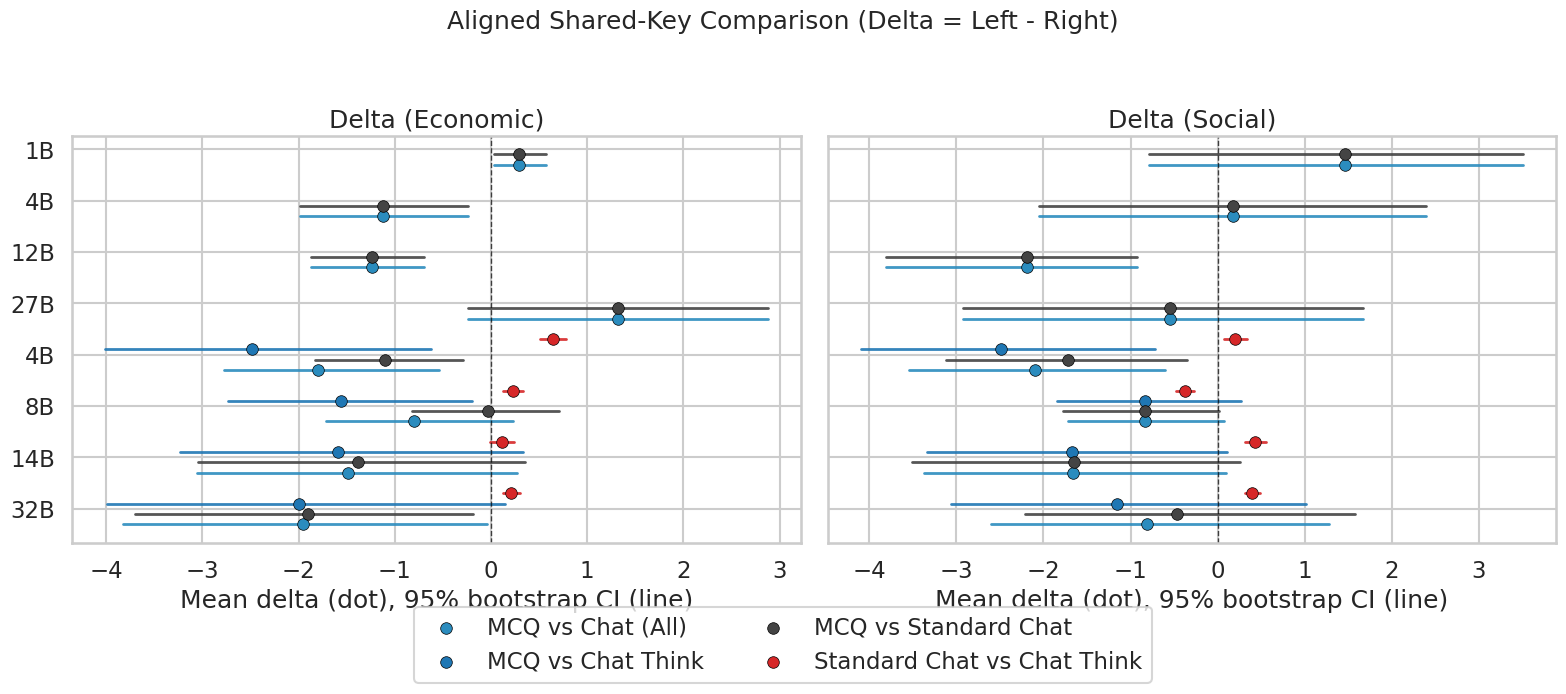

In [11]:
def bootstrap_interval(values, draws=6000, seed=7):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    indices = rng.integers(0, values.size, size=(draws, values.size))
    samples = values[indices].mean(axis=1)
    return float(np.mean(values)), float(np.quantile(samples, 0.025)), float(np.quantile(samples, 0.975))


def plot_mcq_chat_deltas(overlap_df, output_path):
    if overlap_df.empty:
        print("No MCQ vs Chat overlap rows available.")
        return

    records = []
    for (comparison_name, base_model), sub_df in overlap_df.groupby(["comparison", "base_model"], observed=True):
        econ_mean, econ_low, econ_high = bootstrap_interval(
            sub_df["score_econ_chat"] - sub_df["score_econ_mcq"]
        )
        soc_mean, soc_low, soc_high = bootstrap_interval(
            sub_df["score_soc_chat"] - sub_df["score_soc_mcq"]
        )
        records.append(
            {
                "comparison": comparison_name,
                "base_model": base_model,
                "size_label": extract_size_label(base_model),
                "econ_mean": econ_mean,
                "econ_low": econ_low,
                "econ_high": econ_high,
                "soc_mean": soc_mean,
                "soc_low": soc_low,
                "soc_high": soc_high,
            }
        )

    plot_df = pd.DataFrame(records)
    if plot_df.empty:
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
    color_map = {
        "MCQ vs Chat (All)": "#2b8cbe",
        "MCQ vs Standard Chat": "#444444",
        "MCQ vs Chat Think": "#1f77b4",
        "Standard Chat vs Chat Think": "#d62728",
    }

    for ax, dim_prefix, title in [
        (axes[0], "econ", "Delta (Economic)"),
        (axes[1], "soc", "Delta (Social)"),
    ]:
        y_positions = {model_name: index for index, model_name in enumerate(PRIMARY_BASE_MODELS[::-1])}
        offset_map = {
            "MCQ vs Chat (All)": -0.30,
            "MCQ vs Standard Chat": -0.10,
            "MCQ vs Chat Think": 0.10,
            "Standard Chat vs Chat Think": 0.30,
        }

        for _, row in plot_df.iterrows():
            if row["base_model"] not in y_positions:
                continue
            y = y_positions[row["base_model"]] + offset_map.get(row["comparison"], 0.0)
            mean_value = row[f"{dim_prefix}_mean"]
            low = row[f"{dim_prefix}_low"]
            high = row[f"{dim_prefix}_high"]
            ax.plot(
                [low, high],
                [y, y],
                color=color_map[row["comparison"]],
                lw=2.0,
                alpha=0.9,
            )
            ax.scatter(
                mean_value,
                y,
                color=color_map[row["comparison"]],
                s=70,
                edgecolor="black",
                linewidth=0.5,
                label=row["comparison"],
                zorder=3,
            )

        ax.axvline(0, color="black", lw=1.0, linestyle="--", alpha=0.7)
        ax.set_yticks(list(y_positions.values()))
        ax.set_yticklabels([extract_size_label(model_name) for model_name in PRIMARY_BASE_MODELS[::-1]])
        ax.set_xlabel("Mean delta (dot), 95% bootstrap CI (line)")
        ax.set_title(title)

    handles = []
    labels = []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    dedup = dict(zip(labels, handles))
    fig.legend(dedup.values(), dedup.keys(), loc="lower center", ncol=2, frameon=True)
    fig.suptitle("Aligned Shared-Key Comparison (Delta = Left - Right)", fontsize=18, y=0.98)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()


plot_mcq_chat_deltas(mcq_chat_overlap, PLOTS_DIR / "03_mcq_vs_chat_aligned_deltas.png")

In [12]:
qwen_pair_cols = [
    "base_model",
    "ideology",
    "language",
    "context_combo",
    "instr_combo",
    "reasoning_mode",
    "persona_combo",
    "key_type",
    "perm_id",
    "suffix_idx",
]

qwen_chat = combined_df[
    (combined_df["source"] == "chat") & (combined_df["base_model"].isin(QWEN_MODELS))
].copy()

qwen_no_think = (
    qwen_chat[qwen_chat["method_label"] == "Chat no_think"]
    .groupby(qwen_pair_cols, dropna=False)[["score_econ", "score_soc"]]
    .mean()
    .reset_index()
)

qwen_think = (
    qwen_chat[qwen_chat["method_label"] == "Chat think"]
    .groupby(qwen_pair_cols, dropna=False)[["score_econ", "score_soc"]]
    .mean()
    .reset_index()
)

qwen_mode_pairs = qwen_no_think.merge(
    qwen_think,
    on=qwen_pair_cols,
    how="inner",
    suffixes=("_no_think", "_think"),
)
if not qwen_mode_pairs.empty and qwen_mode_pairs["base_model"].isna().any():
    missing_base = int(qwen_mode_pairs["base_model"].isna().sum())
    print(f"Warning: dropping {missing_base} Qwen pair rows with NaN base_model.")
    qwen_mode_pairs = qwen_mode_pairs[qwen_mode_pairs["base_model"].notna()].copy()

qwen_mode_pairs.to_csv(TABLES_DIR / "qwen_think_vs_no_think_pairs.csv", index=False)
print(f"Qwen think vs no_think pairs: {len(qwen_mode_pairs)}")
print(qwen_mode_pairs.groupby("base_model").size() if not qwen_mode_pairs.empty else "Empty")

Qwen think vs no_think pairs: 7160
base_model
Qwen3-14B    1790
Qwen3-32B    1790
Qwen3-4B     1790
Qwen3-8B     1790
dtype: int64


In [13]:
qwen_tasks = []
if not qwen_mode_pairs.empty:
    # Overall
    for label, think_col, no_think_col in [
        ("Economic", "score_econ_think", "score_econ_no_think"),
        ("Social", "score_soc_think", "score_soc_no_think"),
    ]:
        qwen_tasks.append((
            "think vs no_think", "Overall", label,
            qwen_mode_pairs[think_col].to_numpy(),
            qwen_mode_pairs[no_think_col].to_numpy(), 42,
            "Chat think", "Chat no_think",
        ))

    # Per model
    for base_model, sub_df in qwen_mode_pairs.groupby("base_model", observed=True):
        for label, think_col, no_think_col in [
            ("Economic", "score_econ_think", "score_econ_no_think"),
            ("Social", "score_soc_think", "score_soc_no_think"),
        ]:
            qwen_tasks.append((
                "think vs no_think", base_model, label,
                sub_df[think_col].to_numpy(),
                sub_df[no_think_col].to_numpy(), 123,
                "Chat think", "Chat no_think",
            ))

print(f"Qwen think vs no_think tasks: {len(qwen_tasks)}")

qwen_mode_all_bayes = []
qwen_mode_all_robust = []
if qwen_tasks:
    with ProcessPoolExecutor(max_workers=N_WORKERS) as executor:
        futures = {executor.submit(_run_comparison_worker, t): t for t in qwen_tasks}
        for future in as_completed(futures):
            bayes, robust = future.result()
            qwen_mode_all_bayes.append(bayes)
            qwen_mode_all_robust.append(robust)

qwen_mode_all_bayes_df = pd.DataFrame(qwen_mode_all_bayes)
qwen_mode_all_robust_df = pd.DataFrame(qwen_mode_all_robust)

qwen_mode_all_bayes_df = ensure_result_columns(qwen_mode_all_bayes_df)
qwen_mode_all_robust_df = ensure_result_columns(qwen_mode_all_robust_df)

for frame in [qwen_mode_all_bayes_df, qwen_mode_all_robust_df]:
    frame["base_model"] = frame["base_model"].fillna("Unknown").astype(str)

# Split overall vs per-model
qwen_mode_bayes_df = qwen_mode_all_bayes_df[qwen_mode_all_bayes_df["base_model"] == "Overall"].copy()
qwen_mode_robust_df = qwen_mode_all_robust_df[qwen_mode_all_robust_df["base_model"] == "Overall"].copy()
qwen_model_bayes_df = qwen_mode_all_bayes_df[qwen_mode_all_bayes_df["base_model"] != "Overall"].copy()
qwen_model_robust_df = qwen_mode_all_robust_df[qwen_mode_all_robust_df["base_model"] != "Overall"].copy()

qwen_mode_robust_df = add_bh_qvalues(qwen_mode_robust_df)
qwen_model_robust_df = add_bh_qvalues(qwen_model_robust_df)
qwen_mode_all_robust_df = add_bh_qvalues(qwen_mode_all_robust_df)
for frame in [qwen_mode_robust_df, qwen_model_robust_df, qwen_mode_all_robust_df]:
    frame["p_value_display"] = frame["perm_p_value"].map(p_value_label)

bayes_cols = [
    "comparison",
    "base_model",
    "dimension",
    "left_label",
    "right_label",
    "delta_definition",
    "n_pairs",
    "observed_mean_diff",
    "posterior_mean_diff",
    "ci_low",
    "ci_high",
    "p_gt_0",
    "p_lt_0",
    "p_rope",
    "baycomp_test",
    "baycomp_left",
    "baycomp_rope",
    "baycomp_right",
]
robust_cols = [
    "comparison",
    "base_model",
    "dimension",
    "left_label",
    "right_label",
    "delta_definition",
    "n_pairs",
    "mean_diff",
    "median_diff",
    "effect_size_dz",
    "perm_p_value",
    "p_value_display",
    "q_value_bh",
    "significant_bh_05",
    "wasserstein",
]

qwen_mode_bayes_df = qwen_mode_bayes_df[bayes_cols].copy()
qwen_mode_robust_df = qwen_mode_robust_df[robust_cols].copy()
qwen_model_bayes_df = qwen_model_bayes_df[bayes_cols].copy()
qwen_model_robust_df = qwen_model_robust_df[robust_cols].copy()

qwen_mode_all_bayes_export = qwen_mode_all_bayes_df[bayes_cols].copy()
qwen_mode_all_robust_export = qwen_mode_all_robust_df[robust_cols].copy()

if qwen_mode_bayes_df["baycomp_test"].isna().all():
    print("Note: baycomp unavailable; baycomp probability columns are NaN.")

qwen_mode_all_bayes_export.to_csv(TABLES_DIR / "qwen_think_vs_no_think_bayesian_summary.csv", index=False)
qwen_mode_all_robust_export.to_csv(TABLES_DIR / "qwen_think_vs_no_think_robust_summary.csv", index=False)

qwen_cluster_rows = []
if not qwen_mode_pairs.empty:
    for dim_name, left_col, right_col in [
        ("Economic", "score_econ_think", "score_econ_no_think"),
        ("Social", "score_soc_think", "score_soc_no_think"),
    ]:
        stats = cluster_bootstrap_mean_diff(qwen_mode_pairs, left_col, right_col, cluster_col="base_model")
        stats.update(
            {
                "comparison": "think vs no_think",
                "dimension": dim_name,
                "left_label": "Chat think",
                "right_label": "Chat no_think",
                "delta_definition": "Chat think - Chat no_think",
            }
        )
        qwen_cluster_rows.append(stats)
qwen_mode_cluster_df = pd.DataFrame(qwen_cluster_rows)
qwen_mode_cluster_df.to_csv(TABLES_DIR / "qwen_think_vs_no_think_cluster_bootstrap_by_model.csv", index=False)

print("Qwen mode Bayesian summary (overall):")
display(qwen_mode_bayes_df)
print("\nQwen mode Bayesian summary (per-model):")
display(qwen_model_bayes_df)
print("\nQwen mode robust summary (overall):")
display(qwen_mode_robust_df)
print("\nQwen mode model-cluster bootstrap CI (overall):")
display(qwen_mode_cluster_df)

Qwen think vs no_think tasks: 10
Qwen mode Bayesian summary (overall):


,comparison,base_model,dimension,left_label,right_label,delta_definition,n_pairs,observed_mean_diff,posterior_mean_diff,ci_low,ci_high,p_gt_0,p_lt_0,p_rope,baycomp_test,baycomp_left,baycomp_rope,baycomp_right
8,think vs no_think,Overall,Social,Chat think,Chat no_think,Chat think - Chat no_think,7160,-0.197207,-0.197312,-0.254408,-0.141412,0.0,1.0,0.96515,SignedRankTest,0.1464,0.0,0.8536
9,think vs no_think,Overall,Economic,Chat think,Chat no_think,Chat think - Chat no_think,7160,-0.332967,-0.332959,-0.388866,-0.276641,0.0,1.0,0.00195,SignedRankTest,0.0000,0.0,1.0000



Qwen mode Bayesian summary (per-model):


,comparison,base_model,dimension,left_label,right_label,delta_definition,n_pairs,observed_mean_diff,posterior_mean_diff,ci_low,ci_high,p_gt_0,p_lt_0,p_rope,baycomp_test,baycomp_left,baycomp_rope,baycomp_right
0,think vs no_think,Qwen3-4B,Economic,Chat think,Chat no_think,Chat think - Chat no_think,1790,-0.668608,-0.668245,-0.799701,-0.538651,0.00000,1.00000,0.00000,SignedRankTest,0.00000,0.0,1.00000
1,think vs no_think,Qwen3-32B,Social,Chat think,Chat no_think,Chat think - Chat no_think,1790,-0.430095,-0.430032,-0.516351,-0.345165,0.00000,1.00000,0.00000,SignedRankTest,0.00000,0.0,1.00000
2,think vs no_think,Qwen3-14B,Economic,Chat think,Chat no_think,Chat think - Chat no_think,1790,-0.154729,-0.154040,-0.273633,-0.032730,0.00655,0.99345,0.94085,SignedRankTest,0.00158,0.0,0.99842
3,think vs no_think,Qwen3-14B,Social,Chat think,Chat no_think,Chat think - Chat no_think,1790,-0.469640,-0.469090,-0.585926,-0.356284,0.00000,1.00000,0.00005,SignedRankTest,0.00000,0.0,1.00000
4,think vs no_think,Qwen3-4B,Social,Chat think,Chat no_think,Chat think - Chat no_think,1790,-0.251154,-0.251103,-0.383610,-0.120947,0.00000,1.00000,0.49480,SignedRankTest,0.48936,0.0,0.51064
5,think vs no_think,Qwen3-32B,Economic,Chat think,Chat no_think,Chat think - Chat no_think,1790,-0.251974,-0.251604,-0.341990,-0.161480,0.00000,1.00000,0.48860,SignedRankTest,0.00000,0.0,1.00000
6,think vs no_think,Qwen3-8B,Social,Chat think,Chat no_think,Chat think - Chat no_think,1790,0.362062,0.361994,0.254685,0.467105,1.00000,0.00000,0.02060,SignedRankTest,1.00000,0.0,0.00000
7,think vs no_think,Qwen3-8B,Economic,Chat think,Chat no_think,Chat think - Chat no_think,1790,-0.256558,-0.255967,-0.360014,-0.152972,0.00000,1.00000,0.45450,SignedRankTest,0.00000,0.0,1.00000



Qwen mode robust summary (overall):


,comparison,base_model,dimension,left_label,right_label,delta_definition,n_pairs,mean_diff,median_diff,effect_size_dz,perm_p_value,p_value_display,q_value_bh,significant_bh_05,wasserstein
8,think vs no_think,Overall,Social,Chat think,Chat no_think,Chat think - Chat no_think,7160,-0.197207,0.051064,-0.081044,0.0002,<0.0002,0.0002,True,0.693039
9,think vs no_think,Overall,Economic,Chat think,Chat no_think,Chat think - Chat no_think,7160,-0.332967,-0.254819,-0.136760,0.0002,<0.0002,0.0002,True,1.018639



Qwen mode model-cluster bootstrap CI (overall):


,n_pairs,n_clusters,observed_mean_diff,cluster_ci_low,cluster_ci_high,comparison,dimension,left_label,right_label,delta_definition
0,7160,4,-0.332967,-0.564449,-0.180186,think vs no_think,Economic,Chat think,Chat no_think,Chat think - Chat no_think
1,7160,4,-0.197207,-0.449867,0.164023,think vs no_think,Social,Chat think,Chat no_think,Chat think - Chat no_think


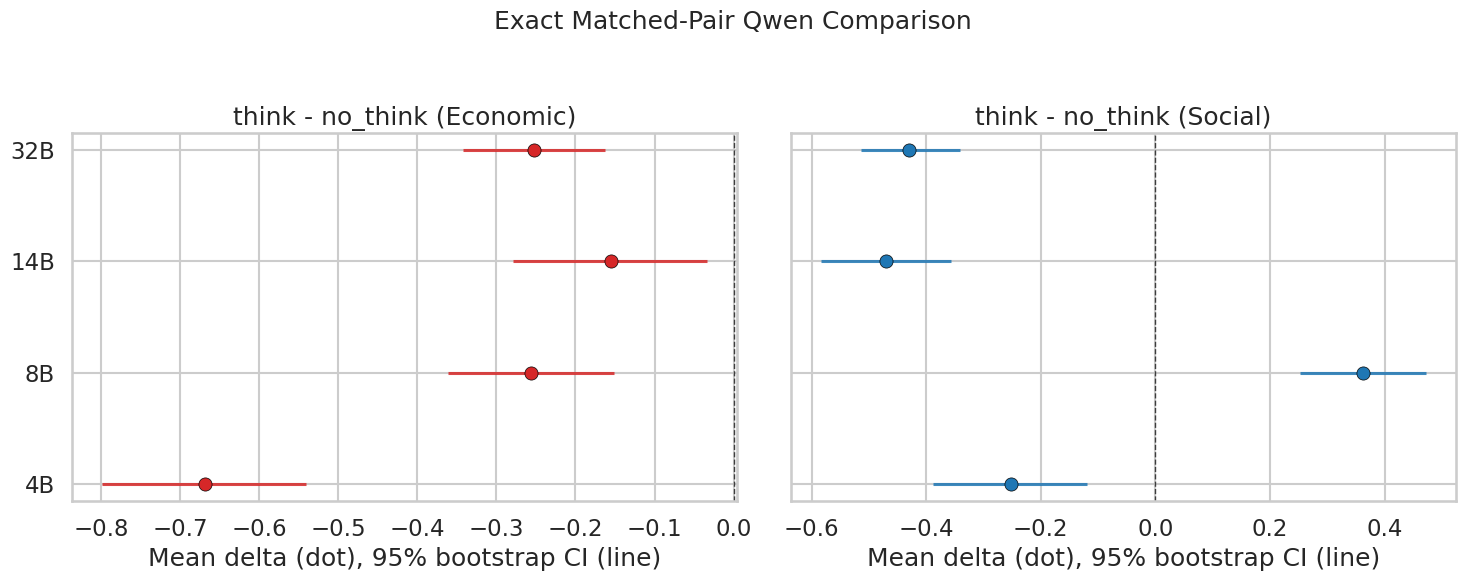

In [14]:
def plot_qwen_mode_deltas(pair_df, output_path):
    if pair_df.empty:
        print("No exact Qwen think/no_think pairs available.")
        return

    records = []
    for base_model, sub_df in pair_df.groupby("base_model", observed=True):
        econ_mean, econ_low, econ_high = bootstrap_interval(
            sub_df["score_econ_think"] - sub_df["score_econ_no_think"]
        )
        soc_mean, soc_low, soc_high = bootstrap_interval(
            sub_df["score_soc_think"] - sub_df["score_soc_no_think"]
        )
        records.append(
            {
                "base_model": base_model,
                "econ_mean": econ_mean,
                "econ_low": econ_low,
                "econ_high": econ_high,
                "soc_mean": soc_mean,
                "soc_low": soc_low,
                "soc_high": soc_high,
            }
        )

    plot_df = pd.DataFrame(records)
    plot_df["base_model"] = pd.Categorical(plot_df["base_model"], categories=QWEN_MODELS, ordered=True)
    plot_df = plot_df.sort_values("base_model").reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

    for ax, dim_prefix, title, color in [
        (axes[0], "econ", "think - no_think (Economic)", "#d62728"),
        (axes[1], "soc", "think - no_think (Social)", "#1f77b4"),
    ]:
        y_positions = np.arange(len(plot_df))
        means = plot_df[f"{dim_prefix}_mean"].to_numpy()
        lows = plot_df[f"{dim_prefix}_low"].to_numpy()
        highs = plot_df[f"{dim_prefix}_high"].to_numpy()

        ax.hlines(y_positions, lows, highs, color=color, lw=2.2, alpha=0.85)
        ax.scatter(means, y_positions, color=color, s=90, edgecolor="black", linewidth=0.5, zorder=3)
        ax.axvline(0, color="black", lw=1.0, linestyle="--", alpha=0.7)
        ax.set_title(title)
        ax.set_xlabel("Mean delta (dot), 95% bootstrap CI (line)")
        ax.set_yticks(y_positions)
        ax.set_yticklabels([extract_size_label(model_name) for model_name in plot_df["base_model"].astype(str)])

    fig.suptitle("Exact Matched-Pair Qwen Comparison", fontsize=18, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()


plot_qwen_mode_deltas(qwen_mode_pairs, PLOTS_DIR / "04_qwen_think_vs_no_think_deltas.png")

In [15]:
# Aggregate factor-level method means for a direct MCQ vs Chat sensitivity view.
factor_cols = ["Context", "Instruction", "Persona", "Key Type", "Permutation", "Reasoning Mode", "Suffix", "Language", "Quantization"]
factor_method = sensitivity_long.copy()
factor_method["method_group"] = factor_method["unified_model"].astype(str).map(
    lambda label: "MCQ"
    if label.endswith("MCQ")
    else "Chat think"
    if label.endswith("Chat think")
    else "Chat no_think"
    if label.endswith("Chat no_think")
    else "Chat"
)
factor_method_mean = (
    factor_method.groupby(["dimension", "method_group"], observed=True)[factor_cols]
    .mean(numeric_only=True)
    .reset_index()
)
factor_method_mean.to_csv(TABLES_DIR / "factor_method_means.csv", index=False)


# ── RQ answerability and conclusions ──

rq_rows = []

# RQ1: Do open-weight LLMs have political biases?
base_positions = summary_table[summary_table["ideology"] == "base"][["unified_model", "econ_mean", "soc_mean"]]
if not base_positions.empty:
    rq_rows.append({
        "RQ": "RQ1",
        "Question": "Do open-weight LLMs have political biases?",
        "CanAnswer": "Descriptive",
        "Evidence": f"Base-model positions span economic=[{base_positions['econ_mean'].min():.2f}, {base_positions['econ_mean'].max():.2f}], social=[{base_positions['soc_mean'].min():.2f}, {base_positions['soc_mean'].max():.2f}].",
        "Conclusion": "Base centroids are displaced from the neutral origin, but this table is descriptive; formal neutral-origin tests should be reported separately if making a significance claim.",
    })

# RQ2: Size-scaling trends within families?
ideology_sd_econ = sensitivity_econ[["unified_model", "Ideology SD"]].copy()
rq_rows.append({
    "RQ": "RQ2",
    "Question": "Are there scaling trends across model sizes within families?",
    "CanAnswer": "Descriptive",
    "Evidence": f"Ideology SD ranges from {ideology_sd_econ['Ideology SD'].min():.3f} to {ideology_sd_econ['Ideology SD'].max():.3f} across unified models.",
    "Conclusion": "Scaling patterns are visible in centroid-separation metrics, but this is a descriptive trend analysis rather than a formal model-size hypothesis test.",
})

# RQ3: Language distributional differences?
mcq_languages = sorted(combined_df.loc[combined_df["source"] == "mcq", "language"].dropna().astype(str).unique())
chat_languages = sorted(combined_df.loc[combined_df["source"] == "chat", "language"].dropna().astype(str).unique())
shared_languages = sorted(set(mcq_languages).intersection(set(chat_languages)))
rq_rows.append({
    "RQ": "RQ3",
    "Question": "Do different languages produce distributional differences in political leanings?",
    "CanAnswer": "MCQ-only descriptive",
    "Evidence": f"MCQ languages={mcq_languages}; Chat languages={chat_languages}; cross-method comparison limited to shared={shared_languages}.",
    "Conclusion": "Language sensitivity can be described within MCQ only. Chat is English-only, so cross-method language effects are under-identified.",
})

# RQ4: MCQ vs Chat differences?
if mcq_chat_overlap.empty or mcq_chat_robust_df.empty:
    rq_rows.append({
        "RQ": "RQ4",
        "Question": "How do MCQ and Chat outputs differ under aligned settings?",
        "CanAnswer": "No",
        "Evidence": "No non-empty shared-key overlap pairs were found.",
        "Conclusion": "Not answerable with current aligned slices.",
    })
else:
    best = (
        mcq_chat_robust_df.assign(abs_mean_diff=lambda x: x["mean_diff"].abs())
        .sort_values("abs_mean_diff", ascending=False)
        .iloc[0]
    )
    rq_rows.append({
        "RQ": "RQ4",
        "Question": "How do MCQ and Chat outputs differ under aligned settings?",
        "CanAnswer": "Inferential, limited overlap",
        "Evidence": f"Pairs={int(mcq_chat_overlap.shape[0])}, strongest delta={best['comparison']} {best['dimension']} mean_diff={best['mean_diff']:.3f}, p_perm={p_value_label(best['perm_p_value'])}, q_BH={best['q_value_bh']:.4f}.",
        "Conclusion": "Overall MCQ-vs-chat shifts are statistically detectable in aligned slices, but MCQ-linked contrasts have only 12 pairs per model and should be framed as conditional on the English+bf16 overlap subset.",
    })

# RQ5: Qwen think vs no_think?
if qwen_mode_pairs.empty or qwen_mode_robust_df.empty:
    rq_rows.append({
        "RQ": "RQ5",
        "Question": "Does Qwen think vs no_think materially change compass scores?",
        "CanAnswer": "No",
        "Evidence": "No exact matched Qwen no_think/think pairs available.",
        "Conclusion": "Not answerable with current data alignment.",
    })
else:
    qbest = (
        qwen_mode_robust_df.assign(abs_mean_diff=lambda x: x["mean_diff"].abs())
        .sort_values("abs_mean_diff", ascending=False)
        .iloc[0]
    )
    rq_rows.append({
        "RQ": "RQ5",
        "Question": "Does Qwen think vs no_think materially change compass scores?",
        "CanAnswer": "Inferential",
        "Evidence": f"Overall strongest={qbest['dimension']} mean_diff={qbest['mean_diff']:.3f}, p_perm={p_value_label(qbest['perm_p_value'])}, q_BH={qbest['q_value_bh']:.4f}, n_pairs={int(qbest['n_pairs'])}.",
        "Conclusion": "Thinking mode is associated with statistically detectable shifts in Qwen, with heterogeneous direction and practical magnitude by size/dimension.",
    })

# RQ6: Persona emulation?
persona_models = summary_table[summary_table["ideology"] != "base"].copy()
if not persona_models.empty:
    n_ideologies = persona_models["ideology"].nunique()
    rq_rows.append({
        "RQ": "RQ6",
        "Question": "Can LLMs emulate personas across the 5 distinct ideological quadrants?",
        "CanAnswer": "Descriptive",
        "Evidence": f"Persona runs cover {n_ideologies} ideologies across all model variants. Compass plots show clear quadrant separation for larger models.",
        "Conclusion": "Persona-conditioned centroids separate visually and geometrically, especially for larger models; formal fidelity tests should be treated as follow-up rather than implied here.",
    })

# RQ7: LHC factor sensitivity?
if factor_method_mean.empty:
    rq_rows.append({
        "RQ": "RQ7",
        "Question": "Do LHC dimensions affect MCQ and Chat differently?",
        "CanAnswer": "No",
        "Evidence": "No factor-sensitivity rows computed.",
        "Conclusion": "Not answerable.",
    })
else:
    rq_rows.append({
        "RQ": "RQ7",
        "Question": "Do LHC dimensions affect MCQ and Chat differently?",
        "CanAnswer": "Descriptive",
        "Evidence": f"Factor means available for method groups={sorted(factor_method_mean['method_group'].unique())}.",
        "Conclusion": "Factor-sensitivity summaries identify candidate sources of variation. Shared factors are comparable across methods; method-specific factors remain design-specific.",
    })

rq_summary_df = pd.DataFrame(rq_rows)
rq_summary_df.to_csv(TABLES_DIR / "rq_answerability_summary.csv", index=False)

print("\n" + "=" * 80)
print("RQ Answerability and Conclusions")
print("=" * 80)
display(rq_summary_df)


RQ Answerability and Conclusions


,RQ,Question,CanAnswer,Evidence,Conclusion
0,RQ1,Do open-weight LLMs have political biases?,Descriptive,"Base-model positions span economic=[-5.07, 0.0...",Base centroids are displaced from the neutral ...
1,RQ2,Are there scaling trends across model sizes wi...,Descriptive,Ideology SD ranges from 0.022 to 6.824 across ...,Scaling patterns are visible in centroid-separ...
2,RQ3,Do different languages produce distributional ...,MCQ-only descriptive,"MCQ languages=['bulgarian', 'czech', 'english'...",Language sensitivity can be described within M...
3,RQ4,How do MCQ and Chat outputs differ under align...,"Inferential, limited overlap","Pairs=7020, strongest delta=MCQ vs Chat Think ...",Overall MCQ-vs-chat shifts are statistically d...
4,RQ5,Does Qwen think vs no_think materially change ...,Inferential,"Overall strongest=Economic mean_diff=-0.333, p...",Thinking mode is associated with statistically...
5,RQ6,Can LLMs emulate personas across the 5 distinc...,Descriptive,Persona runs cover 5 ideologies across all mod...,Persona-conditioned centroids separate visuall...
6,RQ7,Do LHC dimensions affect MCQ and Chat differen...,Descriptive,Factor means available for method groups=['Cha...,Factor-sensitivity summaries identify candidat...


In [16]:
def method_group_from_method_label(method_label: str) -> str:
    method_label = str(method_label)
    if method_label == "MCQ":
        return "MCQ"
    if method_label in {"Chat", "Chat no_think"}:
        return "Standard Chat"
    if method_label == "Chat think":
        return "Chat Think"
    return method_label


def fit_linear_trend(x_vals, y_vals):
    x = np.asarray(x_vals, dtype=float)
    y = np.asarray(y_vals, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if x.size < 3:
        return np.nan, np.nan, np.nan, int(x.size)
    slope, intercept = np.polyfit(x, y, 1)
    corr = float(np.corrcoef(x, y)[0, 1]) if x.size >= 2 else np.nan
    return float(slope), float(intercept), corr, int(x.size)


def fisher_ratio_2d(sub_df, label_col="ideology", x_col="score_econ", y_col="score_soc"):
    tmp = sub_df[[label_col, x_col, y_col]].copy()
    tmp = tmp[np.isfinite(tmp[x_col]) & np.isfinite(tmp[y_col])]
    if tmp.empty or tmp[label_col].nunique() < 2:
        return np.nan

    global_mean = tmp[[x_col, y_col]].mean().to_numpy(dtype=float)
    between_ss = 0.0
    within_ss = 0.0
    for _, group_df in tmp.groupby(label_col, observed=True):
        points = group_df[[x_col, y_col]].to_numpy(dtype=float)
        centroid = points.mean(axis=0)
        between_ss += len(points) * float(np.sum((centroid - global_mean) ** 2))
        within_ss += float(np.sum((points - centroid) ** 2))
    if within_ss <= 0:
        return np.nan
    return float(between_ss / within_ss)


def shift_direction(mean_diff, dimension):
    if not np.isfinite(mean_diff):
        return "NA"
    if abs(mean_diff) < 1e-12:
        return "No shift"
    if dimension == "Economic":
        return "Leftward" if mean_diff < 0 else "Rightward"
    return "Libertarian" if mean_diff < 0 else "Authoritarian"


analysis_df = combined_df.copy()
analysis_df["size_b"] = analysis_df["base_model"].map(extract_size_value)
analysis_df["method_group"] = analysis_df["method_label"].map(method_group_from_method_label)


# ── RQ8: Size x persona fidelity interaction ─────────────────────────────────
rq8_rows = []
for unified_model, sub_df in analysis_df.groupby("unified_model", observed=True):
    if sub_df.empty:
        continue

    centroids = (
        sub_df.groupby("ideology", observed=True)[["score_econ", "score_soc"]]
        .mean()
        .dropna()
    )

    ideology_sd_econ = float(centroids["score_econ"].std()) if not centroids.empty else np.nan
    ideology_sd_soc = float(centroids["score_soc"].std()) if not centroids.empty else np.nan
    ideology_sd_l2 = float(np.sqrt(np.nansum([ideology_sd_econ ** 2, ideology_sd_soc ** 2])))

    mean_distance_from_base = np.nan
    if "base" in centroids.index:
        base_vec = centroids.loc["base", ["score_econ", "score_soc"]].to_numpy(dtype=float)
        non_base = centroids.drop(index="base", errors="ignore")
        if not non_base.empty:
            dist = np.linalg.norm(non_base[["score_econ", "score_soc"]].to_numpy(dtype=float) - base_vec, axis=1)
            mean_distance_from_base = float(np.mean(dist))

    logit_var_econ = float(
        np.sqrt(np.maximum(sub_df["row_intrinsic_var_econ"].sum(), 0.0) / max(len(sub_df), 1))
    )
    logit_var_soc = float(
        np.sqrt(np.maximum(sub_df["row_intrinsic_var_soc"].sum(), 0.0) / max(len(sub_df), 1))
    )
    logit_var_mean = float(np.nanmean([logit_var_econ, logit_var_soc]))

    rq8_rows.append(
        {
            "unified_model": str(unified_model),
            "family": str(sub_df["family"].mode().iat[0]),
            "method_group": str(sub_df["method_group"].mode().iat[0]),
            "base_model": str(sub_df["base_model"].mode().iat[0]),
            "size_b": float(pd.to_numeric(sub_df["size_b"], errors="coerce").dropna().median()),
            "ideology_sd_econ": ideology_sd_econ,
            "ideology_sd_soc": ideology_sd_soc,
            "ideology_sd_l2": ideology_sd_l2,
            "mean_distance_from_base": mean_distance_from_base,
            "fisher_ratio": fisher_ratio_2d(sub_df),
            "logit_distribution_variance_econ": logit_var_econ,
            "logit_distribution_variance_soc": logit_var_soc,
            "logit_distribution_variance": logit_var_mean,
        }
    )

rq8_model_df = pd.DataFrame(rq8_rows)
if not rq8_model_df.empty:
    rq8_model_df = rq8_model_df.sort_values(["family", "method_group", "size_b"]).reset_index(drop=True)
rq8_model_df.to_csv(TABLES_DIR / "rq8_persona_fidelity_metrics.csv", index=False)

rq8_trend_rows = []
if not rq8_model_df.empty:
    for (family, method_group), sub_df in rq8_model_df.groupby(["family", "method_group"], observed=True):
        for metric in [
            "ideology_sd_l2",
            "mean_distance_from_base",
            "fisher_ratio",
            "logit_distribution_variance",
            "logit_distribution_variance_econ",
            "logit_distribution_variance_soc",
        ]:
            slope, intercept, corr, n_points = fit_linear_trend(sub_df["size_b"], sub_df[metric])
            rq8_trend_rows.append(
                {
                    "family": family,
                    "method_group": method_group,
                    "metric": metric,
                    "n_points": n_points,
                    "slope_per_B": slope,
                    "intercept": intercept,
                    "pearson_r": corr,
                }
            )

rq8_trend_df = pd.DataFrame(rq8_trend_rows)
rq8_trend_df.to_csv(TABLES_DIR / "rq8_size_persona_trends.csv", index=False)


# ── RQ9: Is think-mode shift ideology-dependent? ─────────────────────────────
rq9_rows = []
if not qwen_mode_pairs.empty:
    for ideology, sub_df in qwen_mode_pairs.groupby("ideology", observed=True):
        for dimension, think_col, no_think_col in [
            ("Economic", "score_econ_think", "score_econ_no_think"),
            ("Social", "score_soc_think", "score_soc_no_think"),
        ]:
            bayes = paired_bayes_bootstrap(sub_df[think_col], sub_df[no_think_col], seed=77)
            robust = paired_robust_summary(sub_df[think_col], sub_df[no_think_col])
            rq9_rows.append(
                {
                    "ideology": ideology,
                    "dimension": dimension,
                    "n_pairs": int(robust["n_pairs"]),
                    "mean_diff": robust["mean_diff"],
                    "median_diff": robust["median_diff"],
                    "effect_size_dz": robust["effect_size_dz"],
                    "perm_p_value": robust["perm_p_value"],
                    "posterior_mean_diff": bayes["posterior_mean_diff"],
                    "ci_low": bayes["ci_low"],
                    "ci_high": bayes["ci_high"],
                    "p_lt_0": bayes["p_lt_0"],
                    "p_gt_0": bayes["p_gt_0"],
                    "p_rope": bayes["p_rope"],
                    "direction": shift_direction(robust["mean_diff"], dimension),
                }
            )

rq9_df = pd.DataFrame(rq9_rows)
if not rq9_df.empty:
    rq9_df = add_bh_qvalues(rq9_df)
    rq9_df["p_value_display"] = rq9_df["perm_p_value"].map(p_value_label)
    rq9_df = rq9_df.sort_values(["dimension", "ideology"]).reset_index(drop=True)
rq9_df.to_csv(TABLES_DIR / "rq9_think_shift_by_ideology.csv", index=False)


# ── RQ10: Sycophancy under thinking (toward base centroid) ──────────────────
qwen_standard_df = analysis_df[
    (analysis_df["source"] == "chat")
    & (analysis_df["base_model"].isin(QWEN_MODELS))
    & (analysis_df["method_group"] == "Standard Chat")
].copy()
qwen_think_df = analysis_df[
    (analysis_df["source"] == "chat")
    & (analysis_df["base_model"].isin(QWEN_MODELS))
    & (analysis_df["method_group"] == "Chat Think")
].copy()

std_centroids = (
    qwen_standard_df.groupby(["base_model", "ideology"], observed=True)[["score_econ", "score_soc"]]
    .mean()
    .rename(columns={"score_econ": "econ_std", "score_soc": "soc_std"})
)
think_centroids = (
    qwen_think_df.groupby(["base_model", "ideology"], observed=True)[["score_econ", "score_soc"]]
    .mean()
    .rename(columns={"score_econ": "econ_think", "score_soc": "soc_think"})
)

centroid_pairs = std_centroids.join(think_centroids, how="inner").reset_index()

rq10_rows = []
for model_name in QWEN_MODELS:
    model_df = centroid_pairs[centroid_pairs["base_model"] == model_name].copy()
    base_row = model_df[model_df["ideology"] == "base"]
    if base_row.empty:
        continue

    base_std = base_row[["econ_std", "soc_std"]].iloc[0].to_numpy(dtype=float)
    base_think = base_row[["econ_think", "soc_think"]].iloc[0].to_numpy(dtype=float)

    for _, row in model_df[model_df["ideology"] != "base"].iterrows():
        std_vec = np.array([row["econ_std"], row["soc_std"]], dtype=float)
        think_vec = np.array([row["econ_think"], row["soc_think"]], dtype=float)
        dist_std = float(np.linalg.norm(std_vec - base_std))
        dist_think = float(np.linalg.norm(think_vec - base_think))
        toward_base = dist_std - dist_think
        rq10_rows.append(
            {
                "base_model": model_name,
                "ideology": row["ideology"],
                "dist_to_base_standard": dist_std,
                "dist_to_base_think": dist_think,
                "toward_base": toward_base,
            }
        )

rq10_detail_df = pd.DataFrame(rq10_rows)
rq10_detail_df.to_csv(TABLES_DIR / "rq10_sycophancy_toward_base_detail.csv", index=False)

rq10_summary_rows = []
if not rq10_detail_df.empty:
    for model_name, sub_df in rq10_detail_df.groupby("base_model", observed=True):
        mean_val, ci_low, ci_high = bootstrap_interval(sub_df["toward_base"].to_numpy(), draws=6000, seed=11)
        rq10_summary_rows.append(
            {
                "base_model": model_name,
                "n_ideologies": int(len(sub_df)),
                "mean_toward_base": mean_val,
                "ci_low": ci_low,
                "ci_high": ci_high,
            }
        )

    all_mean, all_low, all_high = bootstrap_interval(rq10_detail_df["toward_base"].to_numpy(), draws=6000, seed=23)
    rq10_summary_rows.append(
        {
            "base_model": "Overall",
            "n_ideologies": int(len(rq10_detail_df)),
            "mean_toward_base": all_mean,
            "ci_low": all_low,
            "ci_high": all_high,
        }
    )

rq10_summary_df = pd.DataFrame(rq10_summary_rows)
rq10_summary_df.to_csv(TABLES_DIR / "rq10_sycophancy_toward_base_summary.csv", index=False)


# ── RQ11: Cross-model distributional similarity (Wasserstein matrices) ──────
available_models = [
    label for label in UNIFIED_MODEL_ORDER
    if label in set(analysis_df["unified_model"].astype(str).unique())
]

rq11_econ_mat = pd.DataFrame(np.nan, index=available_models, columns=available_models)
rq11_soc_mat = pd.DataFrame(np.nan, index=available_models, columns=available_models)

for idx_a, model_a in enumerate(available_models):
    econ_a = analysis_df.loc[analysis_df["unified_model"].astype(str) == model_a, "score_econ"].to_numpy(dtype=float)
    soc_a = analysis_df.loc[analysis_df["unified_model"].astype(str) == model_a, "score_soc"].to_numpy(dtype=float)
    econ_a = econ_a[np.isfinite(econ_a)]
    soc_a = soc_a[np.isfinite(soc_a)]

    for idx_b, model_b in enumerate(available_models):
        if idx_b < idx_a:
            rq11_econ_mat.iat[idx_a, idx_b] = rq11_econ_mat.iat[idx_b, idx_a]
            rq11_soc_mat.iat[idx_a, idx_b] = rq11_soc_mat.iat[idx_b, idx_a]
            continue

        econ_b = analysis_df.loc[analysis_df["unified_model"].astype(str) == model_b, "score_econ"].to_numpy(dtype=float)
        soc_b = analysis_df.loc[analysis_df["unified_model"].astype(str) == model_b, "score_soc"].to_numpy(dtype=float)
        econ_b = econ_b[np.isfinite(econ_b)]
        soc_b = soc_b[np.isfinite(soc_b)]

        econ_dist = np.nan if (econ_a.size == 0 or econ_b.size == 0) else float(wasserstein_distance(econ_a, econ_b))
        soc_dist = np.nan if (soc_a.size == 0 or soc_b.size == 0) else float(wasserstein_distance(soc_a, soc_b))
        rq11_econ_mat.iat[idx_a, idx_b] = econ_dist
        rq11_soc_mat.iat[idx_a, idx_b] = soc_dist

rq11_mean_mat = (rq11_econ_mat + rq11_soc_mat) / 2.0
rq11_econ_mat.to_csv(TABLES_DIR / "rq11_wasserstein_matrix_economic.csv")
rq11_soc_mat.to_csv(TABLES_DIR / "rq11_wasserstein_matrix_social.csv")
rq11_mean_mat.to_csv(TABLES_DIR / "rq11_wasserstein_matrix_mean.csv")

rq11_pair_rows = []
for i, model_a in enumerate(available_models):
    for j in range(i + 1, len(available_models)):
        model_b = available_models[j]
        econ_dist = rq11_econ_mat.loc[model_a, model_b]
        soc_dist = rq11_soc_mat.loc[model_a, model_b]
        rq11_pair_rows.append(
            {
                "model_a": model_a,
                "model_b": model_b,
                "wasserstein_economic": econ_dist,
                "wasserstein_social": soc_dist,
                "wasserstein_mean": float(np.nanmean([econ_dist, soc_dist])),
            }
        )

rq11_pairs_df = pd.DataFrame(rq11_pair_rows).sort_values("wasserstein_mean") if rq11_pair_rows else pd.DataFrame()
rq11_pairs_df.to_csv(TABLES_DIR / "rq11_wasserstein_pairs.csv", index=False)


# ── RQ12: Permutation x model size interaction ───────────────────────────────
def fit_perm_size_interaction(sub_df, target_col):
    tmp = sub_df[[target_col, "perm_id", "size_b", "ideology"]].copy()
    tmp = tmp[
        np.isfinite(pd.to_numeric(tmp[target_col], errors="coerce"))
        & np.isfinite(pd.to_numeric(tmp["size_b"], errors="coerce"))
    ]
    tmp["perm_id"] = pd.to_numeric(tmp["perm_id"], errors="coerce")
    tmp = tmp[np.isfinite(tmp["perm_id"])]
    if tmp.empty:
        return {
            "n_rows": 0,
            "n_perm_levels": 0,
            "n_sizes": 0,
            "rmse_reduced": np.nan,
            "rmse_full": np.nan,
            "delta_rmse": np.nan,
            "interaction_rms": np.nan,
            "interaction_max_abs": np.nan,
        }

    if tmp["perm_id"].nunique() < 2 or tmp["size_b"].nunique() < 2 or len(tmp) < 20:
        return {
            "n_rows": int(len(tmp)),
            "n_perm_levels": int(tmp["perm_id"].nunique()),
            "n_sizes": int(tmp["size_b"].nunique()),
            "rmse_reduced": np.nan,
            "rmse_full": np.nan,
            "delta_rmse": np.nan,
            "interaction_rms": np.nan,
            "interaction_max_abs": np.nan,
        }

    tmp["size_c"] = tmp["size_b"].astype(float) - float(tmp["size_b"].astype(float).mean())
    y = tmp[target_col].astype(float).to_numpy(dtype=float)

    perm_dummies = pd.get_dummies(tmp["perm_id"].astype(int).astype(str), prefix="perm", drop_first=True, dtype=float)
    ideol_dummies = pd.get_dummies(tmp["ideology"].astype(str), prefix="ideol", drop_first=True, dtype=float)

    x_reduced = pd.concat(
        [
            pd.Series(1.0, index=tmp.index, name="_intercept_"),
            tmp[["size_c"]],
            perm_dummies,
            ideol_dummies,
        ],
        axis=1,
    )
    x_full = x_reduced.copy()
    interaction_cols = []
    for col in perm_dummies.columns:
        inter_col = f"{col}:size"
        x_full[inter_col] = perm_dummies[col].to_numpy(dtype=float) * tmp["size_c"].to_numpy(dtype=float)
        interaction_cols.append(inter_col)

    if not interaction_cols:
        return {
            "n_rows": int(len(tmp)),
            "n_perm_levels": int(tmp["perm_id"].nunique()),
            "n_sizes": int(tmp["size_b"].nunique()),
            "rmse_reduced": np.nan,
            "rmse_full": np.nan,
            "delta_rmse": np.nan,
            "interaction_rms": np.nan,
            "interaction_max_abs": np.nan,
        }

    xr = x_reduced.to_numpy(dtype=float)
    xf = x_full.to_numpy(dtype=float)
    if xr.shape[0] <= xf.shape[1]:
        return {
            "n_rows": int(len(tmp)),
            "n_perm_levels": int(tmp["perm_id"].nunique()),
            "n_sizes": int(tmp["size_b"].nunique()),
            "rmse_reduced": np.nan,
            "rmse_full": np.nan,
            "delta_rmse": np.nan,
            "interaction_rms": np.nan,
            "interaction_max_abs": np.nan,
        }

    coeff_r, _, rank_r, _ = np.linalg.lstsq(xr, y, rcond=None)
    coeff_f, _, rank_f, _ = np.linalg.lstsq(xf, y, rcond=None)

    resid_r = y - xr @ coeff_r
    resid_f = y - xf @ coeff_f

    df_r = max(len(y) - rank_r, 1)
    df_f = max(len(y) - rank_f, 1)
    rmse_r = float(np.sqrt(np.sum(resid_r ** 2) / df_r))
    rmse_f = float(np.sqrt(np.sum(resid_f ** 2) / df_f))

    coeff_f_series = pd.Series(coeff_f, index=x_full.columns)
    inter_vals = coeff_f_series[interaction_cols].to_numpy(dtype=float)

    return {
        "n_rows": int(len(tmp)),
        "n_perm_levels": int(tmp["perm_id"].nunique()),
        "n_sizes": int(tmp["size_b"].nunique()),
        "rmse_reduced": rmse_r,
        "rmse_full": rmse_f,
        "delta_rmse": float(rmse_r - rmse_f),
        "interaction_rms": float(np.sqrt(np.mean(inter_vals ** 2))),
        "interaction_max_abs": float(np.max(np.abs(inter_vals))),
    }


rq12_rows = []
for (family, method_group), sub_df in analysis_df.groupby(["family", "method_group"], observed=True):
    for dimension, target_col in [("Economic", "score_econ"), ("Social", "score_soc")]:
        stats = fit_perm_size_interaction(sub_df, target_col)
        stats.update(
            {
                "family": family,
                "method_group": method_group,
                "dimension": dimension,
            }
        )
        rq12_rows.append(stats)

rq12_df = pd.DataFrame(rq12_rows)
rq12_df.to_csv(TABLES_DIR / "rq12_perm_size_interaction.csv", index=False)

model_meta = (
    analysis_df.groupby("unified_model", observed=True)
    .agg(
        family=("family", lambda s: s.mode().iat[0]),
        method_group=("method_group", lambda s: s.mode().iat[0]),
        size_b=("size_b", "median"),
    )
    .reset_index()
)
rq12_perm_metric = sensitivity_long[["unified_model", "dimension", "Permutation"]].merge(
    model_meta, on="unified_model", how="left"
)

rq12_trend_rows = []
for (family, method_group, dimension), sub_df in rq12_perm_metric.groupby(
    ["family", "method_group", "dimension"],
    observed=True,
):
    slope, intercept, corr, n_points = fit_linear_trend(sub_df["size_b"], sub_df["Permutation"])
    rq12_trend_rows.append(
        {
            "family": family,
            "method_group": method_group,
            "dimension": dimension,
            "n_points": n_points,
            "slope_per_B": slope,
            "intercept": intercept,
            "pearson_r": corr,
        }
    )

rq12_trend_df = pd.DataFrame(rq12_trend_rows)
rq12_trend_df.to_csv(TABLES_DIR / "rq12_permutation_sensitivity_size_trends.csv", index=False)


# ── Consolidated summary for RQ8-RQ12 ────────────────────────────────────────
rq8_12_rows = []

if not rq8_trend_df.empty and rq8_trend_df["slope_per_B"].notna().any():
    best_rq8 = rq8_trend_df.assign(abs_slope=lambda x: x["slope_per_B"].abs()).sort_values("abs_slope", ascending=False).iloc[0]
    rq8_12_rows.append(
        {
            "RQ": "RQ8",
            "Question": "Do model sizes interact with persona emulation fidelity?",
            "CanAnswer": "Descriptive",
            "Evidence": f"Strongest slope={best_rq8['metric']} in {best_rq8['family']} {best_rq8['method_group']}: slope={best_rq8['slope_per_B']:.4f} per B.",
            "Conclusion": "Size-fidelity trends are quantifiable via centroid separation, Fisher ratio, and size-trend regressions; these slopes are descriptive unless paired with formal uncertainty tests.",
        }
    )
else:
    rq8_12_rows.append(
        {
            "RQ": "RQ8",
            "Question": "Do model sizes interact with persona emulation fidelity?",
            "CanAnswer": "No",
            "Evidence": "Insufficient points for stable size-trend fits.",
            "Conclusion": "Need additional model sizes to quantify the interaction robustly.",
        }
    )

if not rq9_df.empty:
    strongest_rq9 = rq9_df.assign(abs_mean=lambda x: x["mean_diff"].abs()).sort_values("abs_mean", ascending=False).iloc[0]
    rq8_12_rows.append(
        {
            "RQ": "RQ9",
            "Question": "Is the think-mode shift ideology-dependent?",
            "CanAnswer": "Inferential",
            "Evidence": f"Largest ideology-specific shift: {strongest_rq9['ideology']} {strongest_rq9['dimension']} mean_diff={strongest_rq9['mean_diff']:.3f}, p_perm={p_value_label(strongest_rq9['perm_p_value'])}, q_BH={strongest_rq9['q_value_bh']:.4f}.",
            "Conclusion": "Think-mode shifts differ by ideology and are statistically detectable in matched-pair tests; practical magnitude should be judged with ROPE columns.",
        }
    )
else:
    rq8_12_rows.append(
        {
            "RQ": "RQ9",
            "Question": "Is the think-mode shift ideology-dependent?",
            "CanAnswer": "No",
            "Evidence": "No ideology-conditioned Qwen think/no_think matched pairs.",
            "Conclusion": "Not answerable from current pair table.",
        }
    )

if not rq10_summary_df.empty:
    overall_rq10 = rq10_summary_df[rq10_summary_df["base_model"] == "Overall"]
    if not overall_rq10.empty:
        row = overall_rq10.iloc[0]
        rq8_12_rows.append(
            {
                "RQ": "RQ10",
                "Question": "Does thinking increase sycophancy (move personas toward base stance)?",
                "CanAnswer": "Geometric proxy",
                "Evidence": f"Overall toward_base mean={row['mean_toward_base']:.3f}, 95% CI=[{row['ci_low']:.3f}, {row['ci_high']:.3f}] over {int(row['n_ideologies'])} model-ideology centroids.",
                "Conclusion": "Negative values indicate divergence from the base centroid under this geometric proxy. Text-level sycophancy remains a separate qualitative claim.",
            }
        )
    else:
        rq8_12_rows.append(
            {
                "RQ": "RQ10",
                "Question": "Does thinking increase sycophancy (move personas toward base stance)?",
                "CanAnswer": "Partial",
                "Evidence": "Per-model sycophancy table exists but no overall aggregate row was produced.",
                "Conclusion": "Review centroid completeness by ideology.",
            }
        )
else:
    rq8_12_rows.append(
        {
            "RQ": "RQ10",
            "Question": "Does thinking increase sycophancy (move personas toward base stance)?",
            "CanAnswer": "No",
            "Evidence": "No centroid pairs available for Standard Chat vs Chat Think.",
            "Conclusion": "Not answerable from current outputs.",
        }
    )

if not rq11_pairs_df.empty:
    nearest = rq11_pairs_df.iloc[0]
    farthest = rq11_pairs_df.iloc[-1]
    rq8_12_rows.append(
        {
            "RQ": "RQ11",
            "Question": "How similar are score distributions across model variants?",
            "CanAnswer": "Descriptive",
            "Evidence": f"Nearest pair={nearest['model_a']} vs {nearest['model_b']} mean W={nearest['wasserstein_mean']:.3f}; farthest={farthest['model_a']} vs {farthest['model_b']} mean W={farthest['wasserstein_mean']:.3f}.",
            "Conclusion": "Pairwise Wasserstein matrices summarize distributional similarity; no significance test is implied by this table.",
        }
    )
else:
    rq8_12_rows.append(
        {
            "RQ": "RQ11",
            "Question": "How similar are score distributions across model variants?",
            "CanAnswer": "No",
            "Evidence": "No pairwise Wasserstein table produced.",
            "Conclusion": "Not answerable with current model coverage.",
        }
    )

if not rq12_df.empty and rq12_df["delta_rmse"].notna().any():
    best_rq12 = rq12_df.assign(abs_delta=lambda x: x["delta_rmse"].abs()).sort_values("abs_delta", ascending=False).iloc[0]
    rq8_12_rows.append(
        {
            "RQ": "RQ12",
            "Question": "Is there a permutation-by-size interaction?",
            "CanAnswer": "Descriptive",
            "Evidence": f"Largest interaction gain: {best_rq12['family']} {best_rq12['method_group']} {best_rq12['dimension']} delta_rmse={best_rq12['delta_rmse']:.4f}.",
            "Conclusion": "Permutation-by-size terms add very little predictive improvement in this specification; treat this as a small descriptive sensitivity check, not a formal interaction claim.",
        }
    )
else:
    rq8_12_rows.append(
        {
            "RQ": "RQ12",
            "Question": "Is there a permutation-by-size interaction?",
            "CanAnswer": "No",
            "Evidence": "Insufficient variation for stable interaction fits.",
            "Conclusion": "Need broader permutation-size coverage for a robust interaction estimate.",
        }
    )

rq8_12_summary_df = pd.DataFrame(rq8_12_rows)
rq8_12_summary_df.to_csv(TABLES_DIR / "rq8_12_summary.csv", index=False)

rq_full_summary_df = pd.concat([rq_summary_df, rq8_12_summary_df], ignore_index=True)
rq_full_summary_df.to_csv(TABLES_DIR / "rq_answerability_summary_full.csv", index=False)

broad_rq_rows = [
    {
        "MainRQ": "RQ1",
        "Question": "What baseline political-compass positions do open-weight LLMs exhibit?",
        "SubRQs": "Sub-RQ1",
        "Status": "Descriptive",
        "Interpretation": "Use base centroids to characterize model positions. Avoid claiming statistical non-neutrality unless neutral-origin tests are added.",
    },
    {
        "MainRQ": "RQ2",
        "Question": "How do model family, scale, and persona conditioning shape compass positions?",
        "SubRQs": "Sub-RQ2, Sub-RQ6, Sub-RQ8, Sub-RQ11",
        "Status": "Mostly descriptive",
        "Interpretation": "Centroid separation, size slopes, persona metrics, and Wasserstein distances describe structure across models; current outputs do not by themselves establish formal scaling or family effects.",
    },
    {
        "MainRQ": "RQ3",
        "Question": "How does elicitation protocol affect measured political position?",
        "SubRQs": "Sub-RQ4, Sub-RQ5, Sub-RQ9, Sub-RQ10",
        "Status": "Mixed: inferential for paired score shifts; proxy for sycophancy",
        "Interpretation": "Aligned paired tests support MCQ/chat and think/no_think score-shift claims, with the caveat that MCQ-linked overlap is small per model. Sycophancy remains a geometric proxy.",
    },
    {
        "MainRQ": "RQ4",
        "Question": "How sensitive are compass estimates to prompt-design and sampling factors?",
        "SubRQs": "Sub-RQ3, Sub-RQ7, Sub-RQ12",
        "Status": "Descriptive sensitivity analysis",
        "Interpretation": "Language, LHC-factor, and permutation-size outputs identify sensitivity patterns and design limitations. They should be framed as robustness diagnostics unless formal factor tests are added.",
    },
]
broad_rq_summary_df = pd.DataFrame(broad_rq_rows)
broad_rq_summary_df.to_csv(TABLES_DIR / "broad_rq_summary.csv", index=False)

print("\n" + "=" * 80)
print("Additional RQs (8-12)")
print("=" * 80)
display(rq8_12_summary_df)
print("\nBroad RQ structure")
display(broad_rq_summary_df)
print("\nSaved tables:")
print(" - rq8_persona_fidelity_metrics.csv")
print(" - rq8_size_persona_trends.csv")
print(" - rq9_think_shift_by_ideology.csv")
print(" - rq10_sycophancy_toward_base_detail.csv")
print(" - rq10_sycophancy_toward_base_summary.csv")
print(" - rq11_wasserstein_matrix_economic.csv")
print(" - rq11_wasserstein_matrix_social.csv")
print(" - rq11_wasserstein_matrix_mean.csv")
print(" - rq11_wasserstein_pairs.csv")
print(" - mcq_vs_chat_cluster_bootstrap_by_model.csv")
print(" - qwen_think_vs_no_think_cluster_bootstrap_by_model.csv")
print(" - rq12_perm_size_interaction.csv")
print(" - rq12_permutation_sensitivity_size_trends.csv")
print(" - rq8_12_summary.csv")
print(" - broad_rq_summary.csv")
print(" - rq_answerability_summary_full.csv")


Additional RQs (8-12)


,RQ,Question,CanAnswer,Evidence,Conclusion
0,RQ8,Do model sizes interact with persona emulation...,Descriptive,Strongest slope=ideology_sd_l2 in Gemma-3 MCQ:...,Size-fidelity trends are quantifiable via cent...
1,RQ9,Is the think-mode shift ideology-dependent?,Inferential,Largest ideology-specific shift: authoritarian...,Think-mode shifts differ by ideology and are s...
2,RQ10,Does thinking increase sycophancy (move person...,Geometric proxy,"Overall toward_base mean=-1.751, 95% CI=[-2.36...",Negative values indicate divergence from the b...
3,RQ11,How similar are score distributions across mod...,Descriptive,Nearest pair=Gemma 4B MCQ vs Qwen 4B MCQ mean ...,Pairwise Wasserstein matrices summarize distri...
4,RQ12,Is there a permutation-by-size interaction?,Descriptive,Largest interaction gain: Gemma-3 Standard Cha...,Permutation-by-size terms add very little pred...



Broad RQ structure


,MainRQ,Question,SubRQs,Status,Interpretation
0,RQ1,What baseline political-compass positions do o...,Sub-RQ1,Descriptive,Use base centroids to characterize model posit...
1,RQ2,"How do model family, scale, and persona condit...","Sub-RQ2, Sub-RQ6, Sub-RQ8, Sub-RQ11",Mostly descriptive,"Centroid separation, size slopes, persona metr..."
2,RQ3,How does elicitation protocol affect measured ...,"Sub-RQ4, Sub-RQ5, Sub-RQ9, Sub-RQ10",Mixed: inferential for paired score shifts; pr...,Aligned paired tests support MCQ/chat and thin...
3,RQ4,How sensitive are compass estimates to prompt-...,"Sub-RQ3, Sub-RQ7, Sub-RQ12",Descriptive sensitivity analysis,"Language, LHC-factor, and permutation-size out..."



Saved tables:
 - rq8_persona_fidelity_metrics.csv
 - rq8_size_persona_trends.csv
 - rq9_think_shift_by_ideology.csv
 - rq10_sycophancy_toward_base_detail.csv
 - rq10_sycophancy_toward_base_summary.csv
 - rq11_wasserstein_matrix_economic.csv
 - rq11_wasserstein_matrix_social.csv
 - rq11_wasserstein_matrix_mean.csv
 - rq11_wasserstein_pairs.csv
 - mcq_vs_chat_cluster_bootstrap_by_model.csv
 - qwen_think_vs_no_think_cluster_bootstrap_by_model.csv
 - rq12_perm_size_interaction.csv
 - rq12_permutation_sensitivity_size_trends.csv
 - rq8_12_summary.csv
 - broad_rq_summary.csv
 - rq_answerability_summary_full.csv
